# Notebook 10 · Integración y validación del dataset maestro territorial

En este notebook integramos las salidas de los Notebooks 01–09 para construir el dataset maestro territorial del TFB.

Utilizamos `codigo_geo` y la base geométrica del Notebook 09 para reunir los indicadores climáticos, territoriales, ambientales, eléctricos, logísticos, digitales y socioeconómicos. Además, incorporamos la dimensión hídrica mediante los indicadores WEI+ de la European Environment Agency.

La base completa mantiene 23 territorios: 22 regiones NUTS 2 comparables de España peninsular y Portugal continental y Andorra como unidad nacional complementaria.

Durante la integración revisamos códigos, unidades, cobertura, valores nulos, duplicados y coherencia territorial. Cuando Andorra no dispone de una fuente equivalente y comparable, conservamos el valor como no disponible en lugar de aplicar imputaciones no justificadas.

El resultado se prepara para el análisis exploratorio del Notebook 11. Los análisis multivariantes y el modelo IIT-CPD se desarrollan en notebooks posteriores.

### Criterio temporal de integración

El periodo 2024–2025 constituye la referencia del análisis climático. Para las demás dimensiones utilizamos la información oficial más reciente y comparable disponible.

Por ello, los indicadores no pertenecen necesariamente al mismo año. En particular, los indicadores hídricos WEI+ corresponden al periodo 2019–2023.

Los años y periodos de referencia los guardamos en las variables de control y trazabilidad. El dataset maestro debe interpretarse como una fotografía territorial integrada y no como una serie temporal homogénea.

## Preparación del entorno

Importamos las librerías necesarias para integrar, validar y visualizar los resultados de los Notebooks 01–09.


In [1]:
# Librería geográfica complementaria
%pip install -q pyogrio

Note: you may need to restart the kernel to use updated packages.


## Configuración general

Definimos `codigo_geo` como clave territorial común y creamos las carpetas donde guardaremos el dataset maestro y sus controles.


In [2]:
# CONFIGURACIÓN GENERAL
from pathlib import Path

import numpy as np
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt

# Claves y ámbito territorial
COLUMNA_CLAVE = "codigo_geo"
CODIGO_ANDORRA = "AD"

N_TERRITORIOS_ESPERADOS = 23
N_NUTS2_ESPERADOS = 22

CRS_GEOGRAFICO = "EPSG:4326"
CRS_PROYECTADO = "EPSG:3035"

# Carpetas
INPUT_DIR = Path("/kaggle/input")

BASE_DIR = (
    Path("/kaggle/working")
    / "10_dataset_maestro_integracion_territorial_iberia"
)

DATOS_DIR = BASE_DIR / "data"
FIGURAS_DIR = BASE_DIR / "figures"
DASHBOARD_DIR = BASE_DIR / "dashboards"
MANIFEST_DIR = BASE_DIR / "manifest"
RELEASE_DIR = BASE_DIR / "release"

for carpeta in [
    DATOS_DIR,
    FIGURAS_DIR,
    DASHBOARD_DIR,
    MANIFEST_DIR,
    RELEASE_DIR,
]:
    carpeta.mkdir(parents=True, exist_ok=True)

print("Carpeta de trabajo:", BASE_DIR)
print(
    "Ámbito:",
    N_NUTS2_ESPERADOS,
    "NUTS 2 + Andorra =",
    N_TERRITORIOS_ESPERADOS,
    "territorios",
)

Carpeta de trabajo: /kaggle/working/10_dataset_maestro_integracion_territorial_iberia
Ámbito: 22 NUTS 2 + Andorra = 23 territorios


## Inventario de fuentes

Buscamos en Kaggle Input las salidas de los Notebooks 01–09 y registramos cuáles están disponibles.

Si falta alguna fuente, activaremos después su sistema de respaldo sin repetir los procesamientos que ya tenemos.


In [3]:
# INVENTARIO DE FUENTES
FUENTES_02A = {
    "01": [
        "clima_cinco_familias_23_territorios_notebook_01.csv"
    ],
    "02": [
        "corine_2018_iberia_continental_andorra_100m.tif",
        "corine_2018_iberia_compatibilidad_suelo_cpd.tif",
    ],
    "03": [
        "osm_geofabrik_capas_iberia.gpkg"
    ],
    "04": [
        "tabla_indicadores_pvgis_potencial_solar_iberia.csv"
    ],
    "05": [
        "areas_protegidas_modelo_sitios_unicos.gpkg",
        "indicador_restriccion_ambiental_modelo_final.csv",
    ],
    "06": [
        "infraestructura_electrica_iberia_osm_final_epsg3035.gpkg"
    ],
    "07": [
        "nodos_digitales_unificados_definitivo_notebook_07.gpkg",
        "osm_overpass_telecom_iberia_recortado_modelo_epsg3035.gpkg",
    ],
    "08": [
        "capa_capital_humano_completa_para_modelo_master_notebook_08.csv"
    ],
    "09": [
        "base_geometrica_iberia_master_notebook_09_EPSG4326.geojson"
    ],
}

# Indexamos Kaggle Input una sola vez
indice_archivos_02a = {}

for ruta in INPUT_DIR.rglob("*"):
    if ruta.is_file():
        indice_archivos_02a.setdefault(
            ruta.name, []
        ).append(ruta)

# Comprobamos los archivos necesarios
registros_02a = []

for notebook, archivos in FUENTES_02A.items():
    for archivo in archivos:

        rutas = indice_archivos_02a.get(archivo, [])

        registros_02a.append({
            "notebook": notebook,
            "archivo": archivo,
            "disponible": bool(rutas),
            "copias": len(rutas),
            "rutas": " | ".join(map(str, rutas)),
        })

df_fuentes_disponibles_02a = pd.DataFrame(
    registros_02a
)

fuentes_ausentes_02a = (
    df_fuentes_disponibles_02a
    .loc[
        ~df_fuentes_disponibles_02a["disponible"],
        "archivo",
    ]
    .tolist()
)

if fuentes_ausentes_02a:
    raise FileNotFoundError(
        "Faltan fuentes necesarias: "
        + ", ".join(fuentes_ausentes_02a)
    )

df_fuentes_disponibles_02a.to_csv(
    MANIFEST_DIR / "inventario_fuentes_notebook_10.csv",
    index=False,
    encoding="utf-8-sig",
)

print(
    "Notebooks cubiertos:",
    f"{len(FUENTES_02A)}/{len(FUENTES_02A)}",
)
print(
    "Archivos clave:",
    len(df_fuentes_disponibles_02a),
)
print(
    "Con varias copias:",
    int(
        df_fuentes_disponibles_02a["copias"]
        .gt(1)
        .sum()
    ),
)

Notebooks cubiertos: 9/9
Archivos clave: 12
Con varias copias: 12


### Selección de archivos

Algunas fuentes aparecen varias veces en Kaggle Input porque existen copias procedentes de los notebooks, datasets finales o respaldos.

Seleccionamos una única ruta por archivo, priorizando las salidas directas de los notebooks cuando están disponibles, y registramos la ruta utilizada para mantener la trazabilidad.

La validez del contenido se comprobará posteriormente durante la carga e integración de cada fuente.

In [4]:
# SELECCIÓN DE ARCHIVOS
def prioridad_02b(ruta):
    texto = str(ruta).lower()
    if "/notebooks/" in texto:
        return 0
    if "_final" in texto and "backup" not in texto:
        return 1
    if "/datasets/" in texto and "backup" not in texto:
        return 2

    if "backup" not in texto:
        return 3
    return 4

RUTAS_FUENTES_02B = {}
registros_02b = []

for notebook, archivos in FUENTES_02A.items():
    for archivo in archivos:

        candidatos = indice_archivos_02a[archivo]

        ruta = min(
            candidatos,
            key=lambda x: (
                prioridad_02b(x),
                str(x),
            ),
        )

        if not ruta.exists() or ruta.stat().st_size == 0:
            raise ValueError(
                f"Fuente no válida: {archivo}"
            )

        RUTAS_FUENTES_02B[archivo] = ruta

        registros_02b.append({
            "notebook": notebook,
            "archivo": archivo,
            "copias": len(candidatos),
            "origen_prioridad": prioridad_02b(ruta),
            "tamano_mb": round(
                ruta.stat().st_size / 1_000_000,
                2,
            ),
            "ruta": str(ruta),
        })

df_fuentes_seleccionadas_02b = pd.DataFrame(
    registros_02b
)
df_fuentes_seleccionadas_02b.to_csv(
    MANIFEST_DIR
    / "fuentes_seleccionadas_notebook_10.csv",
    index=False,
    encoding="utf-8-sig",
)

print(
    "Fuentes seleccionadas:",
    len(RUTAS_FUENTES_02B),
)
print(
    "Salidas directas de notebook:",
    int(
        df_fuentes_seleccionadas_02b[
            "origen_prioridad"
        ].eq(0).sum()
    ),
)
print(
    "Resto de fuentes:",
    int(
        df_fuentes_seleccionadas_02b[
            "origen_prioridad"
        ].ne(0).sum()
    ),
)

Fuentes seleccionadas: 12
Salidas directas de notebook: 11
Resto de fuentes: 1


## Selección de la base territorial del Notebook 09

Cargamos la geometría territorial final del Notebook 09, que usaremos como base común para integrar los resultados de los Notebooks 01–08 mediante
`codigo_geo`.

Comprobamos que contiene los 22 territorios NUTS 2 y Andorra, sin claves duplicadas ni geometrías nulas, vacías o inválidas, y con CRS `EPSG:4326`.

In [5]:
# BASE TERRITORIAL DEL NOTEBOOK 09
archivo_03a = (
    "base_geometrica_iberia_master_notebook_09_EPSG4326.geojson"
)

ruta_base_03a = RUTAS_FUENTES_02B[archivo_03a]

gdf_base_territorial_03a = gpd.read_file(
    ruta_base_03a
)

columnas_03a = {
    COLUMNA_CLAVE,
    "nombre_territorio",
    "pais",
    "geometry",
}

if not columnas_03a.issubset(
    gdf_base_territorial_03a.columns
):
    raise ValueError(
        "Faltan columnas en la base territorial."
    )

gdf_base_territorial_03a[COLUMNA_CLAVE] = (
    gdf_base_territorial_03a[COLUMNA_CLAVE]
    .astype("string")
    .str.strip()
    .str.upper()
)

territorios_03a = len(gdf_base_territorial_03a)

andorra_03a = (
    gdf_base_territorial_03a[COLUMNA_CLAVE]
    .eq(CODIGO_ANDORRA)
    .sum()
)

nuts2_03a = territorios_03a - andorra_03a

geometrias_ok_03a = (
    gdf_base_territorial_03a.geometry.notna().all()
    and not gdf_base_territorial_03a.geometry.is_empty.any()
    and gdf_base_territorial_03a.geometry.is_valid.all()
)

crs_ok_03a = (
    gdf_base_territorial_03a.crs is not None
    and gdf_base_territorial_03a.crs.to_epsg() == 4326
)

estado_03a = (
    territorios_03a == N_TERRITORIOS_ESPERADOS
    and nuts2_03a == N_NUTS2_ESPERADOS
    and andorra_03a == 1
    and not gdf_base_territorial_03a[
        COLUMNA_CLAVE
    ].duplicated().any()
    and geometrias_ok_03a
    and crs_ok_03a
)

if not estado_03a:
    raise ValueError(
        "La base territorial necesita revisión."
    )

pd.DataFrame([{
    "territorios": territorios_03a,
    "nuts2": nuts2_03a,
    "andorra": andorra_03a,
    "crs": str(gdf_base_territorial_03a.crs),
    "estado": "correcto",
}]).to_csv(
    MANIFEST_DIR
    / "control_base_territorial_notebook_09.csv",
    index=False,
    encoding="utf-8-sig",
)

print("Territorios:", territorios_03a)
print("NUTS 2:", nuts2_03a, "| Andorra:", andorra_03a)
print("CRS:", gdf_base_territorial_03a.crs)

Territorios: 23
NUTS 2: 22 | Andorra: 1
CRS: EPSG:4326


## Capital humano del Notebook 08

Cargamos los cinco indicadores originales de población, mercado laboral y formación preparados en el Notebook 08 para los 23 territorios.

Utilizamos la capa completa destinada al dataset maestro y comprobamos que sus códigos territoriales coincidan con la base geográfica del Notebook 09.

In [6]:
# CAPITAL HUMANO DEL NOTEBOOK 08
archivo_03b = (
    "capa_capital_humano_completa_"
    "para_modelo_master_notebook_08.csv"
)
df_capital_humano_03b = pd.read_csv(
    RUTAS_FUENTES_02B[archivo_03b],
    encoding="utf-8-sig",
)
df_capital_humano_03b.columns = (
    df_capital_humano_03b.columns.str.strip()
)

df_capital_humano_03b[COLUMNA_CLAVE] = (
    df_capital_humano_03b[COLUMNA_CLAVE]
    .astype("string")
    .str.strip()
    .str.upper()
)
indicadores_03b = [
    "poblacion_total",
    "poblacion_edad_laboral",
    "densidad_poblacion",
    "tasa_desempleo",
    "nivel_formativo_terciario",
]
anios_03b = [
    f"anio_{indicador}"
    for indicador in indicadores_03b
]
columnas_control_03b = [
    "numero_indicadores_disponibles",
    "cobertura_completa",
    "entra_ranking_nuts2",
    "fuente",
    "motivo_no_ranking",
]
columnas_necesarias_03b = [
    COLUMNA_CLAVE,
    *indicadores_03b,
    *anios_03b,
    *columnas_control_03b,
]
faltantes_03b = (
    set(columnas_necesarias_03b)
    - set(df_capital_humano_03b.columns)
)
if faltantes_03b:
    raise ValueError(
        f"Faltan columnas del Notebook 08: {sorted(faltantes_03b)}"
    )
es_andorra_03b = (
    df_capital_humano_03b[COLUMNA_CLAVE]
    .eq(CODIGO_ANDORRA)
)
es_nuts2_03b = ~es_andorra_03b

codigos_03b = set(
    df_capital_humano_03b[COLUMNA_CLAVE]
)
codigos_base_03b = set(
    gdf_base_territorial_03a[COLUMNA_CLAVE]
)
if (
    len(df_capital_humano_03b) != N_TERRITORIOS_ESPERADOS
    or es_nuts2_03b.sum() != N_NUTS2_ESPERADOS
    or es_andorra_03b.sum() != 1
    or df_capital_humano_03b[
        COLUMNA_CLAVE
    ].duplicated().any()
    or codigos_03b != codigos_base_03b
    or df_capital_humano_03b.loc[
        es_nuts2_03b, indicadores_03b
    ].isna().any().any()
):
    raise ValueError(
        "La tabla del Notebook 08 necesita revisión."
    )

# Andorra debe llegar con desempleo pendiente
andorra_03b = df_capital_humano_03b.loc[
    es_andorra_03b
].iloc[0]

if (
    not pd.isna(andorra_03b["tasa_desempleo"])
    or andorra_03b["numero_indicadores_disponibles"] != 4
    or bool(andorra_03b["cobertura_completa"])
):
    raise ValueError(
        "La cobertura inicial de Andorra necesita revisión."
    )

pd.DataFrame([{
    "territorios": len(df_capital_humano_03b),
    "nuts2": int(es_nuts2_03b.sum()),
    "andorra": int(es_andorra_03b.sum()),
    "indicadores": len(indicadores_03b),
    "indicadores_andorra": 4,
}]).to_csv(
    MANIFEST_DIR
    / "control_capital_humano_notebook_08.csv",
    index=False,
    encoding="utf-8-sig",
)

print("Territorios:", len(df_capital_humano_03b))
print("NUTS 2 completos:", int(es_nuts2_03b.sum()))
print("Indicadores:", len(indicadores_03b))
print("Andorra antes de complemento: 4/5")

Territorios: 23
NUTS 2 completos: 22
Indicadores: 5
Andorra antes de complemento: 4/5


### Complemento del desempleo de Andorra

El Notebook 08 mantiene sin dato la tasa de desempleo de Andorra porque no dispone de una fuente homogénea con Eurostat.

En este notebook incorporamos de forma complementaria la tasa oficial del **1,5 % para 2024**, procedente del FMI. Este valor se documenta como una actualización de fuente y no como una imputación.

Andorra continúa siendo una unidad nacional complementaria y permanece fuera de la comparación NUTS 2.

In [7]:
# Desempleo de Andorra
mascara_ad_03c = (
    df_capital_humano_03b[COLUMNA_CLAVE] == CODIGO_ANDORRA
)

if mascara_ad_03c.sum() != 1:
    raise ValueError("Andorra necesita revisión.")

columnas_ad_03c = [
    "tasa_desempleo",
    "anio_tasa_desempleo",
    "numero_indicadores_disponibles",
    "cobertura_completa",
    "entra_ranking_nuts2"
]

df_capital_humano_03b.loc[
    mascara_ad_03c, columnas_ad_03c
] = [1.5, 2024, 5, True, False]

df_capital_humano_03b.loc[
    mascara_ad_03c, "fuente"
] = "World Bank y FMI Country Report No. 26/88"

df_capital_humano_03b.loc[
    mascara_ad_03c, "motivo_no_ranking"
] = "Andorra es complementaria y no NUTS2."

if df_capital_humano_03b[indicadores_03b].isna().any().any():
    raise ValueError("Quedan indicadores nulos.")

df_capital_humano_03b.to_csv(
    DATOS_DIR / "capital_humano_complementado_andorra.csv",
    index=False,
    encoding="utf-8-sig"
)

print("Andorra: desempleo 1.5 % en 2024")
print("Ranking NUTS 2: no")


Andorra: desempleo 1.5 % en 2024
Ranking NUTS 2: no


## Integración territorial y capital humano

Unimos los cinco indicadores del Notebook 08 con la geometría del Notebook 09 mediante `codigo_geo`.

Conservamos los datos territoriales del Notebook 09 y distinguimos las 22 regiones NUTS 2 de Andorra, que permanece como unidad complementaria.

In [8]:
# INTEGRACIÓN DE LOS NOTEBOOKS 08 Y 09
columnas_capital_04a = indicadores_03b + anios_03b

gdf_maestro_08_09_04a = gdf_base_territorial_03a.merge(
    df_capital_humano_03b[
        [COLUMNA_CLAVE] + columnas_capital_04a
    ],
    on=COLUMNA_CLAVE,
    how="left",
    validate="one_to_one",
)

# Años como enteros
gdf_maestro_08_09_04a[anios_03b] = (
    gdf_maestro_08_09_04a[anios_03b]
    .apply(pd.to_numeric, errors="coerce")
    .astype("Int64")
)

# Ámbito analítico
es_andorra_04a = (
    gdf_maestro_08_09_04a[COLUMNA_CLAVE]
    .eq(CODIGO_ANDORRA)
)

gdf_maestro_08_09_04a["ambito_modelo"] = np.where(
    es_andorra_04a,
    "Andorra_complementaria",
    "NUTS2_comparable",
)

gdf_maestro_nuts2_04a = (
    gdf_maestro_08_09_04a.loc[
        ~es_andorra_04a
    ].copy()
)

gdf_maestro_andorra_04a = (
    gdf_maestro_08_09_04a.loc[
        es_andorra_04a
    ].copy()
)

# Control
nulos_04a = int(
    gdf_maestro_08_09_04a[
        columnas_capital_04a
    ].isna().sum().sum()
)

if (
    len(gdf_maestro_08_09_04a) != N_TERRITORIOS_ESPERADOS
    or len(gdf_maestro_nuts2_04a) != N_NUTS2_ESPERADOS
    or len(gdf_maestro_andorra_04a) != 1
    or nulos_04a != 0
):
    raise ValueError(
        "La integración de los Notebooks 08 y 09 necesita revisión."
    )

pd.DataFrame([{
    "territorios": len(gdf_maestro_08_09_04a),
    "nuts2": len(gdf_maestro_nuts2_04a),
    "andorra": len(gdf_maestro_andorra_04a),
    "campos_capital_humano": len(columnas_capital_04a),
    "nulos": nulos_04a,
}]).to_csv(
    MANIFEST_DIR / "control_integracion_notebooks_08_09.csv",
    index=False,
    encoding="utf-8-sig",
)

print("Territorios:", len(gdf_maestro_08_09_04a))
print(
    "NUTS 2:", len(gdf_maestro_nuts2_04a),
    "| Andorra:", len(gdf_maestro_andorra_04a),
)
print(
    "Campos de capital humano:",
    len(columnas_capital_04a),
)

Territorios: 23
NUTS 2: 22 | Andorra: 1
Campos de capital humano: 10


La integración reúne correctamente los 23 territorios: 22 regiones NUTS 2 y Andorra.

Los cinco indicadores de capital humano y sus años se incorporan sin nulos ni duplicados mediante `codigo_geo`.

## Integración de los Notebooks 01–07

Reutilizamos las salidas procesadas de los Notebooks 01–07, sin repetir las descargas ni los tratamientos ya realizados.

Las fuentes espaciales las territorializamos usando la base geográfica del Notebook 09 y las fuentes tabulares las integramos mediante `codigo_geo`.

En cada bloque comprobamos la cobertura territorial, los posibles duplicados y la coherencia de los datos antes de incorporarlos al dataset maestro.

### Cobertura del suelo CORINE 2018

Calculamos los indicadores territoriales a partir de los rásteres procesados en el Notebook 02, sin repetir su descarga ni reclasificación.

Andorra mantiene valores ausentes porque la cobertura CORINE disponible es parcial.

In [9]:
# TERRITORIALIZACIÓN DE CORINE 2018
import rasterio
from rasterio.mask import mask

ruta_corine = RUTAS_FUENTES_02B[
    "corine_2018_iberia_continental_andorra_100m.tif"
]
ruta_compat = RUTAS_FUENTES_02B[
    "corine_2018_iberia_compatibilidad_suelo_cpd.tif"
]
grupos_corine_05a = {
    "corine_superficies_artificiales_pct": range(1, 12),
    "corine_superficies_agricolas_pct": range(12, 23),
    "corine_zonas_forestales_naturales_pct": range(23, 37),
    "corine_humedales_pct": range(37, 42),
    "corine_masas_agua_pct": range(42, 44),
}
grupos_compat_05a = {
    "corine_excluido_pct": [0],
    "corine_compatibilidad_baja_pct": [1],
    "corine_compatibilidad_media_pct": [2],
    "corine_compatibilidad_alta_pct": [3],
}
variables_corine_05a = (
    list(grupos_corine_05a)
    + list(grupos_compat_05a)
    + ["corine_compat_media_0_3"]
)

def extraer(src, geom, validos):
    datos = mask(
        src, [geom.__geo_interface__],
        crop=True, filled=False
    )[0].compressed()

    return datos[np.isin(datos, validos)]

def porcentaje(datos, codigos):
    return (
        np.isin(datos, codigos).mean() * 100
        if len(datos) else np.nan
    )

registros = []

with rasterio.open(ruta_corine) as corine, \
     rasterio.open(ruta_compat) as compat:

    if (
        corine.crs != compat.crs
        or corine.shape != compat.shape
        or corine.transform != compat.transform
    ):
        raise ValueError("Los rásteres CORINE no coinciden.")

    territorios = gdf_base_territorial_03a.to_crs(corine.crs)
    area_pixel = abs(corine.res[0] * corine.res[1])

    for _, t in territorios.iterrows():

        valores = extraer(
            corine, t.geometry, range(1, 45)
        )
        tierra = valores[valores != 44]

        comp = extraer(
            compat, t.geometry, [0, 1, 2, 3]
        )

        fila = {
            COLUMNA_CLAVE: t[COLUMNA_CLAVE],
            "corine_cobertura_geometria_pct":
                min(100, len(valores) * area_pixel / t.geometry.area * 100),
            "corine_compat_media_0_3":
                comp.mean() if len(comp) else np.nan,
        }

        for nombre, codigos in grupos_corine_05a.items():
            fila[nombre] = porcentaje(tierra, codigos)

        for nombre, codigos in grupos_compat_05a.items():
            fila[nombre] = porcentaje(comp, codigos)

        registros.append(fila)

df_corine_territorial_05a = pd.DataFrame(registros)

es_andorra_05a = (
    df_corine_territorial_05a[COLUMNA_CLAVE] == CODIGO_ANDORRA
)

comparables_05a = ~es_andorra_05a

df_corine_territorial_05a["corine_dato_comparable"] = comparables_05a
df_corine_territorial_05a["corine_tratamiento"] = np.where(
    es_andorra_05a,
    "andorra_no_comparable",
    "cobertura_suficiente",
)

df_corine_territorial_05a.loc[
    es_andorra_05a,
    variables_corine_05a,
] = np.nan


if (
    len(df_corine_territorial_05a) != N_TERRITORIOS_ESPERADOS
    or comparables_05a.sum() != N_NUTS2_ESPERADOS
    or df_corine_territorial_05a.loc[
        comparables_05a, variables_corine_05a
    ].isna().any().any()
    or df_corine_territorial_05a.loc[
        comparables_05a, "corine_cobertura_geometria_pct"
    ].lt(90).any()
):
    raise ValueError("CORINE necesita revisión.")

df_corine_territorial_05a.to_csv(
    DATOS_DIR / "corine_indicadores_territoriales.csv",
    index=False,
    encoding="utf-8-sig",
)

print("Territorios:", len(df_corine_territorial_05a))
print(
    "Comparables:", int(comparables_05a.sum()),
    "| Andorra no comparable:", int(es_andorra_05a.sum()),
)
print("Variables CORINE:", len(variables_corine_05a))

Territorios: 23
Comparables: 22 | Andorra no comparable: 1
Variables CORINE: 10


In [10]:
# INTEGRACIÓN DE CORINE
columnas_control_05b = [
    "corine_cobertura_geometria_pct",
    "corine_dato_comparable",
    "corine_tratamiento",
]

columnas_corine_05b = (
    variables_corine_05a + columnas_control_05b
)

gdf_maestro_05b = gdf_maestro_08_09_04a.merge(
    df_corine_territorial_05a[
        [COLUMNA_CLAVE] + columnas_corine_05b
    ],
    on=COLUMNA_CLAVE,
    how="left",
    validate="one_to_one",
)

# Controles
es_andorra_05b = (
    gdf_maestro_05b[COLUMNA_CLAVE] == CODIGO_ANDORRA
)

nulos_nuts2_05b = (
    gdf_maestro_05b.loc[
        ~es_andorra_05b,
        variables_corine_05a,
    ]
    .isna()
    .sum()
    .sum()
)

nulos_andorra_05b = (
    gdf_maestro_05b.loc[
        es_andorra_05b,
        variables_corine_05a,
    ]
    .isna()
    .sum()
    .sum()
)

if (
    len(gdf_maestro_05b) != N_TERRITORIOS_ESPERADOS
    or nulos_nuts2_05b != 0
    or nulos_andorra_05b != len(variables_corine_05a)
    or gdf_maestro_05b["corine_dato_comparable"].sum()
       != N_NUTS2_ESPERADOS
):
    raise ValueError("La integración CORINE necesita revisión.")

pd.DataFrame([{
    "territorios": len(gdf_maestro_05b),
    "variables_corine": len(variables_corine_05a),
    "comparables": int(
        gdf_maestro_05b["corine_dato_comparable"].sum()
    ),
}]).to_csv(
    MANIFEST_DIR / "control_integracion_corine.csv",
    index=False,
    encoding="utf-8-sig",
)

print("Territorios:", len(gdf_maestro_05b))
print("Variables CORINE:", len(variables_corine_05a))
print(
    "Comparables:",
    int(gdf_maestro_05b["corine_dato_comparable"].sum()),
    "| Andorra: no comparable",
)

Territorios: 23
Variables CORINE: 10
Comparables: 22 | Andorra: no comparable


La integración incorpora 10 indicadores CORINE y 3 campos de control para los 23 territorios.

Los 22 territorios NUTS 2 tienen valores comparables. En Andorra los indicadores CORINE se mantienen como no disponibles al no disponer de una cobertura equivalente y suficientemente homogénea.


### Logística y accesibilidad

Territorializamos las carreteras principales y los núcleos poblados del Notebook 03 sobre la base territorial del Notebook 09.

Calculamos longitudes, recuentos y densidades por territorio, registrando también los elementos que quedan sin asignar.


In [11]:
# TERRITORIALIZACIÓN DE LOGÍSTICA
ruta_logistica_06a = RUTAS_FUENTES_02B["osm_geofabrik_capas_iberia.gpkg"]

alta_06a = {
    "motorway", "motorway_link", "trunk",
    "trunk_link", "primary", "primary_link"
}
secondary_06a = {"secondary", "secondary_link"}
places_validos_06a = ["city", "hamlet", "town", "village"]

# Trabajamos en EPSG:3035 porque permite calcular longitudes y densidades.
territorios_06a = gdf_base_territorial_03a[
    [COLUMNA_CLAVE, "area_km2", "geometry"]
].to_crs(CRS_PROYECTADO)

# CARRETERAS
# Recortamos las vías por territorio y calculamos sus kilómetros.
roads_06a = gpd.read_file(
    ruta_logistica_06a, layer="roads_principales_iberia"
).to_crs(CRS_PROYECTADO)
roads_06a = roads_06a[
    roads_06a["fclass"].isin(alta_06a | secondary_06a)
]
roads_t_06a = gpd.overlay(
    roads_06a[["osm_id", "fclass", "geometry"]],
    territorios_06a[[COLUMNA_CLAVE, "geometry"]],
    how="intersection"
)
roads_t_06a["km"] = roads_t_06a.length / 1000
roads_t_06a["alta_km"] = np.where(
    roads_t_06a["fclass"].isin(alta_06a), roads_t_06a["km"], 0
)
roads_t_06a["secondary_km"] = np.where(
    roads_t_06a["fclass"].isin(secondary_06a), roads_t_06a["km"], 0
)

df_roads_06a = roads_t_06a.groupby(COLUMNA_CLAVE).agg(
    logistica_road_tramos_n=("osm_id", "size"),
    logistica_road_total_km=("km", "sum"),
    logistica_road_alta_capacidad_km=("alta_km", "sum"),
    logistica_road_secondary_km=("secondary_km", "sum")
)

# NÚCLEOS POBLADOS
# Asignamos city, town, village y hamlet a cada territorio.
places_06a = gpd.read_file(
    ruta_logistica_06a, layer="places_interes_iberia"
).to_crs(CRS_PROYECTADO)
places_06a = places_06a[
    places_06a["fclass"].isin(places_validos_06a)
].copy()
places_06a["population"] = pd.to_numeric(
    places_06a["population"], errors="coerce"
)
places_t_06a = gpd.sjoin(
    places_06a,
    territorios_06a[[COLUMNA_CLAVE, "geometry"]],
    how="inner",
    predicate="within"
)

puntos_no_asignados_06a = len(places_06a) - len(places_t_06a)

df_places_06a = places_t_06a.groupby(COLUMNA_CLAVE).agg(
    logistica_places_total_n=("osm_id", "size"),
    logistica_places_poblacion_total=("population", "sum")
)
df_clases_06a = pd.crosstab(
    places_t_06a[COLUMNA_CLAVE], places_t_06a["fclass"]
).reindex(columns=places_validos_06a, fill_value=0)
df_clases_06a.columns = [
    f"logistica_{c}_n" for c in places_validos_06a
]

# TABLA FINAL
# Reunimos carreteras y núcleos y calculamos densidades.
df_logistica_territorial_06a = (
    territorios_06a.set_index(COLUMNA_CLAVE)[["area_km2"]]
    .join([df_roads_06a, df_places_06a, df_clases_06a])
    .fillna(0)
)
df_logistica_territorial_06a[
    "logistica_road_total_km_por_1000km2"
] = df_logistica_territorial_06a["logistica_road_total_km"] / \
    df_logistica_territorial_06a["area_km2"] * 1000

df_logistica_territorial_06a[
    "logistica_road_alta_capacidad_km_por_1000km2"
] = df_logistica_territorial_06a["logistica_road_alta_capacidad_km"] / \
    df_logistica_territorial_06a["area_km2"] * 1000

df_logistica_territorial_06a[
    "logistica_places_n_por_1000km2"
] = df_logistica_territorial_06a["logistica_places_total_n"] / \
    df_logistica_territorial_06a["area_km2"] * 1000

variables_logistica_06a = [
    c for c in df_logistica_territorial_06a.columns
    if c != "area_km2"
]
df_logistica_territorial_06a = (
    df_logistica_territorial_06a
    .reset_index()[[COLUMNA_CLAVE] + variables_logistica_06a]
)

# Control final
if (
    len(df_logistica_territorial_06a) != N_TERRITORIOS_ESPERADOS
    or df_logistica_territorial_06a[variables_logistica_06a]
       .isna().any().any()
):
    raise ValueError("La logística necesita revisión.")

df_logistica_territorial_06a.to_csv(
    DATOS_DIR / "logistica_indicadores_territoriales.csv",
    index=False,
    encoding="utf-8-sig"
)

print("Territorios:", len(df_logistica_territorial_06a))
print("Variables logísticas:", len(variables_logistica_06a))
print("Puntos no asignados:", puntos_no_asignados_06a)

Territorios: 23
Variables logísticas: 13
Puntos no asignados: 2025


Los núcleos no asignados quedan fuera de las 23 geometrías analizadas o sobre sus límites territoriales.

Se registran como control y no se reasignan automáticamente ni se incorporan a los indicadores territoriales.

In [12]:
# INTEGRACIÓN DE LOGÍSTICA
gdf_maestro_06b = gdf_maestro_05b.merge(
    df_logistica_territorial_06a[
        [COLUMNA_CLAVE] + variables_logistica_06a
    ],
    on=COLUMNA_CLAVE,
    how="left",
    validate="one_to_one"
)

datos_06b = gdf_maestro_06b[variables_logistica_06a]

if (
    len(gdf_maestro_06b) != N_TERRITORIOS_ESPERADOS
    or datos_06b.isna().any().any()
    or (datos_06b < 0).any().any()
    or gdf_maestro_06b.crs.to_epsg() != 4326
):
    raise ValueError("La integración logística necesita revisión.")

pd.DataFrame([{
    "territorios": len(gdf_maestro_06b),
    "campos_logisticos": len(variables_logistica_06a)
}]).to_csv(
    MANIFEST_DIR / "control_integracion_logistica.csv",
    index=False,
    encoding="utf-8-sig"
)

print("Territorios:", len(gdf_maestro_06b))
print("Campos logísticos:", len(variables_logistica_06a))

Territorios: 23
Campos logísticos: 13


### Potencial solar PVGIS

Territorializamos los 24 puntos procesados en el Notebook 04 y calculamos nueve indicadores solares para los 23 territorios.

Asignamos los puntos por ubicación o proximidad. En dos regiones portuguesas utilizamos puntos históricos como proxy y dejamos este tratamiento registrado. No repetimos las consultas a PVGIS.


In [13]:
# TERRITORIALIZACIÓN PVGIS
ruta_pvgis_07a = RUTAS_FUENTES_02B[
    "tabla_indicadores_pvgis_potencial_solar_iberia.csv"
]

mapa_pvgis_07a = {
    "produccion_anual_kwh_kwp": "pvgis_produccion_anual_kwh_kwp",
    "irradiacion_anual_kwh_m2": "pvgis_irradiacion_anual_kwh_m2",
    "perdidas_totales_pct": "pvgis_perdidas_totales_pct",
    "produccion_max_mensual_kwh_kwp": "pvgis_produccion_max_mensual_kwh_kwp",
    "produccion_min_mensual_kwh_kwp": "pvgis_produccion_min_mensual_kwh_kwp",
    "produccion_media_mensual_calculada_kwh_kwp": "pvgis_produccion_media_mensual_kwh_kwp",
    "desviacion_mensual_kwh_kwp": "pvgis_desviacion_mensual_kwh_kwp",
    "variabilidad_mensual_kwh_kwp": "pvgis_amplitud_mensual_kwh_kwp",
    "coef_variacion_mensual": "pvgis_coef_variacion_mensual",
}

variables_pvgis_07a = list(mapa_pvgis_07a.values()) + [
    "pvgis_puntos_fuente_n",
    "pvgis_proxy_historico",
    "pvgis_rescate_nearest",
    "pvgis_tratamiento",
]

# Cargamos y comprobamos los 24 puntos del Notebook 04.
df_pvgis_07a = pd.read_csv(ruta_pvgis_07a, encoding="utf-8-sig")
numericas_07a = ["lat", "lon", *mapa_pvgis_07a]

df_pvgis_07a[numericas_07a] = (
    df_pvgis_07a[numericas_07a]
    .apply(pd.to_numeric, errors="coerce")
)

if (
    len(df_pvgis_07a) != 24
    or df_pvgis_07a["id_punto"].duplicated().any()
    or df_pvgis_07a[numericas_07a].isna().any().any()
):
    raise ValueError("Los puntos PVGIS necesitan revisión.")

# Asignación territorial de los puntos.
puntos_07a = gpd.GeoDataFrame(
    df_pvgis_07a,
    geometry=gpd.points_from_xy(df_pvgis_07a["lon"], df_pvgis_07a["lat"]),
    crs=CRS_GEOGRAFICO,
).to_crs(CRS_PROYECTADO)

territorios_07a = gdf_base_territorial_03a[
    [COLUMNA_CLAVE, "geometry"]
].to_crs(CRS_PROYECTADO)

directos_07a = gpd.sjoin(
    puntos_07a,
    territorios_07a,
    how="left",
    predicate="within",
)[["id_punto", COLUMNA_CLAVE]].dropna().drop_duplicates("id_punto")

directos_07a["pvgis_proxy_historico"] = False
directos_07a["pvgis_rescate_nearest"] = False

# Dos puntos quedan fuera por poco: los asignamos hasta 2 km.
pendientes_07a = puntos_07a[
    ~puntos_07a["id_punto"].isin(directos_07a["id_punto"])
]

cercanos_07a = (
    gpd.sjoin_nearest(
        pendientes_07a,
        territorios_07a,
        max_distance=2000,
        distance_col="distancia_m",
    )
    .sort_values("distancia_m")
    .drop_duplicates("id_punto")
    [["id_punto", COLUMNA_CLAVE]]
)
cercanos_07a["pvgis_proxy_historico"] = False
cercanos_07a["pvgis_rescate_nearest"] = True

# Dos puntos históricos se reutilizan como proxy territorial.
proxies_07a = pd.DataFrame({
    "id_punto": ["PT_LIS_LIS", "PT_CEN_COI"],
    COLUMNA_CLAVE: ["PT1B", "PT1D"],
    "pvgis_proxy_historico": True,
    "pvgis_rescate_nearest": False,
})

# Calculamos la media PVGIS por territorio.
asignaciones_07a = pd.concat(
    [directos_07a, cercanos_07a, proxies_07a],
    ignore_index=True,
).merge(
    df_pvgis_07a[["id_punto", *mapa_pvgis_07a]],
    on="id_punto",
)

agregacion_07a = {c: "mean" for c in mapa_pvgis_07a}
agregacion_07a.update({
    "id_punto": "nunique",
    "pvgis_proxy_historico": "max",
    "pvgis_rescate_nearest": "max",
})

resumen_07a = (
    asignaciones_07a
    .groupby(COLUMNA_CLAVE)
    .agg(agregacion_07a)
    .rename(columns={
        **mapa_pvgis_07a,
        "id_punto": "pvgis_puntos_fuente_n",
    })
    .reset_index()
)

resumen_07a["pvgis_tratamiento"] = np.select(
    [
        resumen_07a["pvgis_proxy_historico"],
        resumen_07a["pvgis_rescate_nearest"],
        resumen_07a["pvgis_puntos_fuente_n"] > 1,
    ],
    ["proxy_historico", "proximidad", "media_varios_puntos"],
    default="punto_unico",
)

df_pvgis_territorial_07a = (
    gdf_base_territorial_03a[[COLUMNA_CLAVE]]
    .merge(resumen_07a, on=COLUMNA_CLAVE, how="left")
)

if (
    len(df_pvgis_territorial_07a) != N_TERRITORIOS_ESPERADOS
    or df_pvgis_territorial_07a[variables_pvgis_07a].isna().any().any()
    or df_pvgis_territorial_07a["pvgis_proxy_historico"].sum() != 2
    or df_pvgis_territorial_07a["pvgis_rescate_nearest"].sum() != 2
):
    raise ValueError("PVGIS necesita revisión.")

df_pvgis_territorial_07a.to_csv(
    DATOS_DIR / "pvgis_indicadores_territoriales.csv",
    index=False,
    encoding="utf-8-sig",
)

print("Puntos:", len(df_pvgis_07a), "| Territorios:", len(df_pvgis_territorial_07a))
print(
    "Proxies:", int(df_pvgis_territorial_07a["pvgis_proxy_historico"].sum()),
    "| Proximidad:", int(df_pvgis_territorial_07a["pvgis_rescate_nearest"].sum()),
)
print("Campos PVGIS:", len(variables_pvgis_07a))

Puntos: 24 | Territorios: 23
Proxies: 2 | Proximidad: 2
Campos PVGIS: 13


In [14]:
# INTEGRACIÓN DE PVGIS
gdf_maestro_07b = gdf_maestro_06b.merge(
    df_pvgis_territorial_07a[
        [COLUMNA_CLAVE] + variables_pvgis_07a
    ],
    on=COLUMNA_CLAVE,
    how="left",
    validate="one_to_one"
)

if (
    len(gdf_maestro_07b) != N_TERRITORIOS_ESPERADOS
    or gdf_maestro_07b[
        variables_pvgis_07a
    ].isna().any().any()
):
    raise ValueError("La integración PVGIS necesita revisión.")

pd.DataFrame([{
    "territorios": len(gdf_maestro_07b),
    "campos_pvgis": len(variables_pvgis_07a)
}]).to_csv(
    MANIFEST_DIR / "control_integracion_pvgis.csv",
    index=False,
    encoding="utf-8-sig"
)

print("Territorios:", len(gdf_maestro_07b))
print("Campos PVGIS:", len(variables_pvgis_07a))

Territorios: 23
Campos PVGIS: 13


Los 23 territorios disponen de información PVGIS: nueve indicadores solares y cuatro campos de control.

La cobertura final incluye dos asignaciones por proximidad y dos proxies históricos, que quedan identificados para mantener la trazabilidad.

### Restricciones ambientales

Calculamos por territorio la superficie protegida y las zonas situadas hasta 2,5, 5 y 10 km de los espacios protegidos procesados en el Notebook 05.

Andorra permanece como unidad complementaria no comparable porque la fuente no ofrece una cobertura equivalente.

In [15]:
# TERRITORIALIZACIÓN AMBIENTAL
import shapely

ruta_areas = RUTAS_FUENTES_02B[
    "areas_protegidas_modelo_sitios_unicos.gpkg"
]
ruta_escenarios = RUTAS_FUENTES_02B[
    "indicador_restriccion_ambiental_modelo_final.csv"
]

variables_ambientales_08a = [
    "ambiental_area_protegida_pct",
    "ambiental_anillo_0_2500m_pct",
    "ambiental_anillo_2500_5000m_pct",
    "ambiental_anillo_5000_10000m_pct",
    "ambiental_densidad_sitios_1000km2",
    "ambiental_fuera_10000m_pct",
    "ambiental_penalizacion_media_0_1",
    "ambiental_area_territorio_km2",
    "ambiental_sitios_intersectan_n",
    "ambiental_fuente_disponible",
    "ambiental_dato_comparable",
    "ambiental_suma_zonas_pct_control",
    "ambiental_tratamiento",
]

# Áreas protegidas y escenarios del Notebook 05
areas = gpd.read_file(
    ruta_areas,
    layer="areas_protegidas_modelo_sitios_unicos"
)[["id_area_modelo", "geometry"]].to_crs(CRS_PROYECTADO)

areas["geometry"] = areas.geometry.apply(shapely.make_valid)
areas = areas.explode(index_parts=False)
areas = areas[
    areas.geometry.geom_type.isin(["Polygon", "MultiPolygon"])
]

escenarios = pd.read_csv(ruta_escenarios).sort_values(
    "distancia_buffer_m"
)
distancias = escenarios["distancia_buffer_m"].to_numpy()
penalizaciones = escenarios["penalizacion_ambiental_0_1"].to_numpy()

territorios = gdf_base_territorial_03a[
    [COLUMNA_CLAVE, "geometry"]
].to_crs(CRS_PROYECTADO)

indice = areas.sindex
filas = []

# Calculamos superficie protegida y proximidad por territorio
for _, t in territorios.iterrows():

    codigo = t[COLUMNA_CLAVE]
    geom = t.geometry
    area_m2 = geom.area
    area_km2 = area_m2 / 1_000_000

    if codigo == CODIGO_ANDORRA:
        fila = {
            COLUMNA_CLAVE: codigo,
            **{v: np.nan for v in variables_ambientales_08a[:7]},
            "ambiental_area_territorio_km2": area_km2,
            "ambiental_sitios_intersectan_n": pd.NA,
            "ambiental_fuente_disponible": False,
            "ambiental_dato_comparable": False,
            "ambiental_suma_zonas_pct_control": np.nan,
            "ambiental_tratamiento": "andorra_sin_cobertura",
        }

    else:
        candidatas = areas.iloc[
            indice.query(geom.buffer(10000), predicate="intersects")
        ]

        if candidatas.empty:
            acumuladas = np.zeros(len(distancias))
        else:
            union = shapely.union_all(candidatas.geometry)
            acumuladas = np.array([
                geom.intersection(
                    union if d == 0 else union.buffer(d)
                ).area
                for d in distancias
            ])

        acumuladas = np.maximum.accumulate(
            np.clip(acumuladas, 0, area_m2)
        )
        zonas = np.diff(np.r_[0, acumuladas, area_m2])
        pct = zonas / area_m2 * 100

        sitios = areas.iloc[
            indice.query(geom, predicate="intersects")
        ]["id_area_modelo"].nunique()

        fila = {
            COLUMNA_CLAVE: codigo,
            "ambiental_area_protegida_pct": pct[0],
            "ambiental_anillo_0_2500m_pct": pct[1],
            "ambiental_anillo_2500_5000m_pct": pct[2],
            "ambiental_anillo_5000_10000m_pct": pct[3],
            "ambiental_densidad_sitios_1000km2":
                sitios / area_km2 * 1000,
            "ambiental_fuera_10000m_pct": pct[4],
            "ambiental_penalizacion_media_0_1":
                np.dot(zonas[:4], penalizaciones) / area_m2,
            "ambiental_area_territorio_km2": area_km2,
            "ambiental_sitios_intersectan_n": sitios,
            "ambiental_fuente_disponible": True,
            "ambiental_dato_comparable": True,
            "ambiental_suma_zonas_pct_control": pct.sum(),
            "ambiental_tratamiento": "buffers_epsg3035",
        }

    filas.append(fila)

df_ambiental_territorial_08a = pd.DataFrame(filas)

comparables = (
    df_ambiental_territorial_08a[COLUMNA_CLAVE] != CODIGO_ANDORRA
)

if (
    len(df_ambiental_territorial_08a) != N_TERRITORIOS_ESPERADOS
    or comparables.sum() != N_NUTS2_ESPERADOS
    or df_ambiental_territorial_08a.loc[
        comparables, variables_ambientales_08a[:7]
    ].isna().any().any()
):
    raise ValueError("El bloque ambiental necesita revisión.")

df_ambiental_territorial_08a.to_csv(
    DATOS_DIR / "ambiental_indicadores_territoriales.csv",
    index=False,
    encoding="utf-8-sig",
)

print(
    "Territorios:", len(df_ambiental_territorial_08a),
    "| Comparables:", int(comparables.sum())
)
print("Campos ambientales:", len(variables_ambientales_08a))

Territorios: 23 | Comparables: 22
Campos ambientales: 13


In [16]:
# INTEGRACIÓN AMBIENTAL
gdf_maestro_08b = gdf_maestro_07b.merge(
    df_ambiental_territorial_08a[
        [COLUMNA_CLAVE] + variables_ambientales_08a
    ],
    on=COLUMNA_CLAVE,
    how="left",
    validate="one_to_one"
)

comparables_08b = (
    gdf_maestro_08b[COLUMNA_CLAVE] != CODIGO_ANDORRA
)

if (
    len(gdf_maestro_08b) != N_TERRITORIOS_ESPERADOS
    or gdf_maestro_08b.loc[
        comparables_08b, variables_ambientales_08a
    ].isna().any().any()
):
    raise ValueError("La integración ambiental necesita revisión.")

pd.DataFrame([{
    "territorios": len(gdf_maestro_08b),
    "campos_ambientales": len(variables_ambientales_08a),
    "comparables": int(comparables_08b.sum())
}]).to_csv(
    MANIFEST_DIR / "control_integracion_ambiental.csv",
    index=False,
    encoding="utf-8-sig"
)

print("Territorios:", len(gdf_maestro_08b))
print("Campos ambientales:", len(variables_ambientales_08a))
print("Comparables:", int(comparables_08b.sum()))

Territorios: 23
Campos ambientales: 13
Comparables: 22


Incorporamos siete indicadores ambientales y seis variables de control.

Las 22 regiones NUTS 2 tienen datos comparables. Andorra permanece como unidad complementaria sin indicadores ambientales equivalentes.

### Infraestructura eléctrica

Territorializamos las líneas eléctricas, la red de alta tensión y las subestaciones procesadas en el Notebook 06.

Calculamos sus longitudes y recuentos por territorio, sin repetir las consultas a OpenStreetMap.

In [17]:
# INFRAESTRUCTURA ELÉCTRICA POR TERRITORIO
ruta = RUTAS_FUENTES_02B[
    "infraestructura_electrica_iberia_osm_final_epsg3035.gpkg"
]

territorios = gdf_base_territorial_03a[
    [COLUMNA_CLAVE, "geometry"]
].to_crs(CRS_PROYECTADO)

territorios["area_km2"] = territorios.area / 1_000_000
union = territorios.geometry.union_all()

# Capas del Notebook 06
lineas = gpd.read_file(
    ruta, layer="lineas_cables_3035"
).to_crs(CRS_PROYECTADO)

alta = gpd.read_file(
    ruta, layer="lineas_cables_alta_tension_110kv_3035"
).to_crs(CRS_PROYECTADO)

subestaciones = gpd.read_file(
    ruta, layer="subestaciones_representativas_3035"
).to_crs(CRS_PROYECTADO)

if lineas.empty or alta.empty or subestaciones.empty:
    raise ValueError("Alguna capa eléctrica está vacía.")

# Longitud de líneas por territorio
def calcular_km(capa, nombre):
    capa = capa[["geometry"]].copy().reset_index(drop=True)
    capa["_id"] = capa.index
    capa["_km_union"] = capa.geometry.intersection(union).length / 1000

    partes = gpd.overlay(
        capa,
        territorios[[COLUMNA_CLAVE, "geometry"]],
        how="intersection",
        keep_geom_type=False
    )

    partes["_km"] = partes.length / 1000
    total = partes.groupby("_id")["_km"].transform("sum")

    partes["_km"] *= partes["_km_union"] / total

    return partes.groupby(COLUMNA_CLAVE)["_km"].sum().rename(nombre)

km_lineas = calcular_km(
    lineas, "electrica_longitud_lineas_km"
)
km_alta = calcular_km(
    alta, "electrica_longitud_alta_tension_110kv_km"
)

# Subestaciones por territorio
subestaciones = subestaciones[["geometry"]].reset_index(drop=True)
subestaciones["_id"] = subestaciones.index

asignadas = gpd.sjoin(
    subestaciones,
    territorios[[COLUMNA_CLAVE, "geometry"]],
    how="inner",
    predicate="intersects"
).drop_duplicates("_id")

n_subestaciones = asignadas.groupby(COLUMNA_CLAVE)["_id"].nunique()
n_subestaciones.name = "electrica_subestaciones_n"

subestaciones_fuera_09a = len(subestaciones) - len(asignadas)

# Tabla territorial
df_electrica_territorial_09a = (
    territorios[[COLUMNA_CLAVE, "area_km2"]]
    .set_index(COLUMNA_CLAVE)
    .join([km_lineas, km_alta, n_subestaciones])
    .fillna(0)
    .reset_index()
)

densidades = {
    "electrica_longitud_lineas_km":
        "electrica_densidad_lineas_km_1000km2",
    "electrica_longitud_alta_tension_110kv_km":
        "electrica_densidad_alta_tension_km_1000km2",
    "electrica_subestaciones_n":
        "electrica_densidad_subestaciones_1000km2",
}

for origen, nueva in densidades.items():
    df_electrica_territorial_09a[nueva] = (
        df_electrica_territorial_09a[origen]
        / df_electrica_territorial_09a["area_km2"] * 1000
    )

variables_electricas_09a = [
    *densidades.keys(),
    *densidades.values()
]

datos = df_electrica_territorial_09a[variables_electricas_09a]

if (
    len(df_electrica_territorial_09a) != N_TERRITORIOS_ESPERADOS
    or datos.isna().any().any()
    or (datos < 0).any().any()
    or (
        df_electrica_territorial_09a[
            "electrica_longitud_alta_tension_110kv_km"
        ]
        > df_electrica_territorial_09a[
            "electrica_longitud_lineas_km"
        ]
    ).any()
):
    raise ValueError("Los indicadores eléctricos necesitan revisión.")

df_electrica_territorial_09a.to_csv(
    DATOS_DIR / "electrica_indicadores_territoriales.csv",
    index=False,
    encoding="utf-8-sig"
)

print("Territorios:", len(df_electrica_territorial_09a))
print("Variables eléctricas:", len(variables_electricas_09a))
print("Subestaciones fuera:", subestaciones_fuera_09a)

Territorios: 23
Variables eléctricas: 6
Subestaciones fuera: 441


In [18]:
# SELECCIÓN DE LA FUENTE ELÉCTRICA
import pyogrio

archivo = "infraestructura_electrica_iberia_osm_final_epsg3035.gpkg"

capas = [
    "lineas_cables_3035",
    "lineas_cables_alta_tension_110kv_3035",
    "subestaciones_representativas_3035"
]

esperados = (124709, 11450, 23366)

# Comprobamos primero la fuente que ya había seleccionado 02B
ruta_actual = RUTAS_FUENTES_02B[archivo]

conteos_actual = tuple(
    pyogrio.read_info(ruta_actual, layer=c)["features"]
    for c in capas
)
fuente_ya_valida_09a = conteos_actual == esperados

# Solo buscamos otra copia si la actual no es la validada
if fuente_ya_valida_09a:
    ruta_electrica_09a = ruta_actual
else:
    validas = [
        ruta for ruta in indice_archivos_02a[archivo]
        if tuple(
            pyogrio.read_info(ruta, layer=c)["features"]
            for c in capas
        ) == esperados
    ]

    if not validas:
        raise ValueError("No encontramos la fuente eléctrica validada.")

    ruta_electrica_09a = validas[0]
    RUTAS_FUENTES_02B[archivo] = ruta_electrica_09a

print("Fuente ya válida:", fuente_ya_valida_09a)
print("Conteos:", esperados)
print("Fuente:", ruta_electrica_09a)

Fuente ya válida: True
Conteos: (124709, 11450, 23366)
Fuente: /kaggle/input/notebooks/aemjeloy/06-infraestructura-electrica-osm-overpass-iberia/06_infraestructura_electrica_osm_overpass_iberia/processed/geopackage/infraestructura_electrica_iberia_osm_final_epsg3035.gpkg


In [19]:
# Infraestructura eléctrica por territorio

# Cargamos las tres capas ya validadas en 09A-0
lineas_09a = gpd.read_file(
    ruta_electrica_09a, layer=capas[0]
).to_crs(CRS_PROYECTADO)

alta_09a = gpd.read_file(
    ruta_electrica_09a, layer=capas[1]
).to_crs(CRS_PROYECTADO)

subestaciones_09a = gpd.read_file(
    ruta_electrica_09a, layer=capas[2]
).to_crs(CRS_PROYECTADO)

if min(len(lineas_09a), len(alta_09a), len(subestaciones_09a)) == 0:
    raise ValueError("Alguna capa eléctrica está vacía.")

# Base territorial en CRS métrico
territorios_09a = gdf_base_territorial_03a[
    [COLUMNA_CLAVE, "pais", "nombre_territorio", "geometry"]
].to_crs(CRS_PROYECTADO)

territorios_09a["area_km2"] = (
    territorios_09a.geometry.area / 1_000_000
)

union_territorios_09a = territorios_09a.geometry.union_all()

# Longitud de líneas dentro de cada territorio
def calcular_longitud_09a(capa, nombre):

    capa = capa.loc[
        capa.geometry.notna() & ~capa.geometry.is_empty,
        ["geometry"]
    ].reset_index(drop=True)

    capa["_id"] = capa.index
    capa["_longitud_unica"] = (
        capa.geometry.intersection(union_territorios_09a).length
    )

    fragmentos = gpd.overlay(
        capa,
        territorios_09a[[COLUMNA_CLAVE, "geometry"]],
        how="intersection",
        keep_geom_type=False
    )

    fragmentos["_longitud"] = fragmentos.geometry.length

    total = fragmentos.groupby("_id")[
        "_longitud"
    ].transform("sum")

    fragmentos["_longitud_ajustada"] = np.where(
        total > 0,
        fragmentos["_longitud"]
        * fragmentos["_longitud_unica"]
        / total,
        0
    )

    return (
        fragmentos.groupby(COLUMNA_CLAVE)["_longitud_ajustada"]
        .sum()
        .div(1000)
        .rename(nombre)
    )

longitud_lineas_09a = calcular_longitud_09a(
    lineas_09a,
    "electrica_longitud_lineas_km"
)
longitud_alta_09a = calcular_longitud_09a(
    alta_09a,
    "electrica_longitud_alta_tension_110kv_km"
)

# Asignamos las subestaciones a los territorios
subestaciones_09a = subestaciones_09a[
    ["geometry"]
].reset_index(drop=True)

subestaciones_09a["_id"] = subestaciones_09a.index

asignacion_09a = gpd.sjoin(
    subestaciones_09a,
    territorios_09a[[COLUMNA_CLAVE, "geometry"]],
    predicate="intersects",
    how="inner"
)

asignacion_09a = (
    asignacion_09a
    .sort_values(["_id", COLUMNA_CLAVE])
    .drop_duplicates("_id")
)

numero_subestaciones_09a = (
    asignacion_09a.groupby(COLUMNA_CLAVE)["_id"]
    .nunique()
    .rename("electrica_subestaciones_n")
)

# Construimos los indicadores territoriales
df_electrica_territorial_09a = (
    territorios_09a.drop(columns="geometry")
    .set_index(COLUMNA_CLAVE)
    .join(longitud_lineas_09a)
    .join(longitud_alta_09a)
    .join(numero_subestaciones_09a)
    .fillna(0)
    .reset_index()
)

densidades_09a = {
    "electrica_longitud_lineas_km":
        "electrica_densidad_lineas_km_1000km2",
    "electrica_longitud_alta_tension_110kv_km":
        "electrica_densidad_alta_tension_km_1000km2",
    "electrica_subestaciones_n":
        "electrica_densidad_subestaciones_1000km2"
}

for absoluta, densidad in densidades_09a.items():
    df_electrica_territorial_09a[densidad] = (
        df_electrica_territorial_09a[absoluta]
        / df_electrica_territorial_09a["area_km2"]
        * 1000
    )

variables_electricas_09a = [
    "electrica_longitud_lineas_km",
    "electrica_longitud_alta_tension_110kv_km",
    "electrica_subestaciones_n",
    *densidades_09a.values()
]

# Controles
datos_09a = df_electrica_territorial_09a[
    variables_electricas_09a
]

if (
    len(df_electrica_territorial_09a) != N_TERRITORIOS_ESPERADOS
    or df_electrica_territorial_09a[COLUMNA_CLAVE].duplicated().any()
    or datos_09a.isna().any().any()
    or (datos_09a < 0).any().any()
    or (
        df_electrica_territorial_09a[
            "electrica_longitud_alta_tension_110kv_km"
        ]
        > df_electrica_territorial_09a[
            "electrica_longitud_lineas_km"
        ] + 1e-6
    ).any()
):
    raise ValueError("Los indicadores eléctricos necesitan revisión.")

# Guardado
df_electrica_territorial_09a.to_csv(
    DATOS_DIR / "electrica_indicadores_territoriales.csv",
    index=False,
    encoding="utf-8-sig"
)

subestaciones_fuera_09a = (
    len(subestaciones_09a)
    - asignacion_09a["_id"].nunique()
)

print(
    "Registros fuente:",
    len(lineas_09a), "líneas |",
    len(alta_09a), "alta tensión |",
    len(subestaciones_09a), "subestaciones"
)
print("Territorios:", len(df_electrica_territorial_09a))
print("Variables eléctricas:", len(variables_electricas_09a))
print("Subestaciones fuera:", subestaciones_fuera_09a)

Registros fuente: 124709 líneas | 11450 alta tensión | 23366 subestaciones
Territorios: 23
Variables eléctricas: 6
Subestaciones fuera: 441


In [20]:
# Integración de los indicadores eléctricos

# Evitamos duplicar variables ya existentes
columnas_repetidas_09b = [
    c for c in variables_electricas_09a
    if c in gdf_maestro_08b.columns
]

if columnas_repetidas_09b:
    raise ValueError(
        f"Campos eléctricos repetidos: {columnas_repetidas_09b}"
    )

# Integramos los indicadores eléctricos
gdf_maestro_09b = gdf_maestro_08b.merge(
    df_electrica_territorial_09a[
        [COLUMNA_CLAVE] + variables_electricas_09a
    ],
    on=COLUMNA_CLAVE,
    how="left",
    validate="one_to_one"
)

gdf_maestro_09b = gpd.GeoDataFrame(
    gdf_maestro_09b,
    geometry="geometry",
    crs=gdf_maestro_08b.crs
)

# Controles de integración
columnas_esperadas_09b = (
    gdf_maestro_08b.shape[1]
    + len(variables_electricas_09a)
)

if (
    gdf_maestro_09b.shape
    != (N_TERRITORIOS_ESPERADOS, columnas_esperadas_09b)
    or gdf_maestro_09b[COLUMNA_CLAVE].duplicated().any()
    or gdf_maestro_09b[
        variables_electricas_09a
    ].isna().any().any()
):
    raise ValueError("La integración eléctrica necesita revisión.")

# Guardamos el control
pd.DataFrame([{
    "territorios": len(gdf_maestro_09b),
    "campos_electricos": len(variables_electricas_09a),
    "subestaciones_fuera": subestaciones_fuera_09a
}]).to_csv(
    MANIFEST_DIR / "control_integracion_electrica.csv",
    index=False,
    encoding="utf-8-sig"
)

# Guardamos el maestro hasta infraestructura eléctrica
ruta_maestro_09b = DATOS_DIR / (
    f"maestro_territorial_hasta_electrica_"
    f"{gdf_maestro_09b.shape[0]}x{gdf_maestro_09b.shape[1]}.gpkg"
)

gdf_maestro_09b.to_file(
    ruta_maestro_09b,
    layer="maestro_hasta_electrica",
    driver="GPKG"
)

print("Territorios:", len(gdf_maestro_09b))
print("Campos eléctricos:", len(variables_electricas_09a))
print("Dimensiones:", gdf_maestro_09b.shape)
print("Maestro guardado en:", ruta_maestro_09b)

Territorios: 23
Campos eléctricos: 6
Dimensiones: (23, 85)
Maestro guardado en: /kaggle/working/10_dataset_maestro_integracion_territorial_iberia/data/maestro_territorial_hasta_electrica_23x85.gpkg


Integramos seis indicadores sobre líneas eléctricas, alta tensión y subestaciones.

Los 23 territorios disponen de datos completos, sin valores nulos.

###  Conectividad digital

Utilizamos las capas procesadas en el Notebook 07 para calcular los nodos digitales y la longitud de las redes de telecomunicaciones de cada territorio.

Asignamos los nodos por ubicación y recuperamos los casos fronterizos mediante proximidad dentro del mismo país. No repetimos las consultas a OpenStreetMap, PeeringDB ni RIPE Atlas.


### Selección de variables digitales

Incorporamos catorce indicadores digitales: seis recuentos de nodos, la longitud de las líneas de telecomunicaciones y siete variables de densidad.

Incluimos torres, centrales de telecomunicaciones, data centers, nodos de red, facilities de PeeringDB y probes de RIPE Atlas. Excluimos oficinas y totales agregados para evitar información redundante.

Esta selección define las variables digitales que se integran en el dataset maestro; la selección posterior de variables para el modelo se realiza en notebooks posteriores.

In [21]:
# Revisión de las fuentes digitales
import pyogrio

# Reutilizamos los archivos del Notebook 07 ya definidos en 02A
archivo_nodos_10a, archivo_osm_10a = FUENTES_02A["07"]

registros_digitales_10a = []

# Revisamos las copias de nodos digitales
for ruta in indice_archivos_02a[archivo_nodos_10a]:
    try:
        nodos = pyogrio.read_info(
            ruta,
            layer="nodos_digitales_modelo"
        )["features"]
    except Exception:
        nodos = None

    registros_digitales_10a.append({
        "archivo": "nodos",
        "ruta": ruta,
        "nodos": nodos
    })

# Revisamos las copias de infraestructura OSM
for ruta in indice_archivos_02a[archivo_osm_10a]:
    try:
        lineas = pyogrio.read_info(
            ruta,
            layer="osm_lineas_telecom_modelo"
        )["features"]

        poligonos = pyogrio.read_info(
            ruta,
            layer="osm_poligonos_telecom_modelo"
        )["features"]

    except Exception:
        lineas, poligonos = None, None

    registros_digitales_10a.append({
        "archivo": "infraestructura_osm",
        "ruta": ruta,
        "lineas": lineas,
        "poligonos": poligonos
    })

df_fuentes_digitales_10a = pd.DataFrame(
    registros_digitales_10a
)

display(df_fuentes_digitales_10a)

,archivo,ruta,nodos,lineas,poligonos
0,nodos,/kaggle/input/datasets/aemjeloy/07-conectivida...,16775.0,NaN,NaN
1,nodos,/kaggle/input/datasets/aemjeloy/24h-copernicus...,16775.0,NaN,NaN
2,nodos,/kaggle/input/notebooks/aemjeloy/07-conectivid...,16770.0,NaN,NaN
3,infraestructura_osm,/kaggle/input/datasets/aemjeloy/07-conectivida...,NaN,153.0,584.0
4,infraestructura_osm,/kaggle/input/datasets/aemjeloy/24h-copernicus...,NaN,153.0,584.0
5,infraestructura_osm,/kaggle/input/notebooks/aemjeloy/07-conectivid...,NaN,153.0,584.0


In [22]:
# Selección de las fuentes digitales
rutas_texto_10a = (
    df_fuentes_digitales_10a["ruta"].astype(str)
)
filtro_dataset_10a = (
    rutas_texto_10a.str.contains("/datasets/")
    & ~rutas_texto_10a.str.contains("24h-copernicus")
)
candidatos_nodos_10a = df_fuentes_digitales_10a.loc[
    (df_fuentes_digitales_10a["archivo"] == "nodos")
    & (df_fuentes_digitales_10a["nodos"] == 16775)
    & filtro_dataset_10a,
    "ruta"
].tolist()
candidatos_osm_10a = df_fuentes_digitales_10a.loc[
    (df_fuentes_digitales_10a["archivo"] == "infraestructura_osm")
    & (df_fuentes_digitales_10a["lineas"] == 153)
    & (df_fuentes_digitales_10a["poligonos"] == 584)
    & filtro_dataset_10a,
    "ruta"
].tolist()

if len(candidatos_nodos_10a) != 1 or len(candidatos_osm_10a) != 1:
    raise ValueError("No podemos seleccionar una fuente digital única.")
ruta_nodos_10a = Path(candidatos_nodos_10a[0])
ruta_osm_10a = Path(candidatos_osm_10a[0])
RUTAS_FUENTES_02B[archivo_nodos_10a] = ruta_nodos_10a
RUTAS_FUENTES_02B[archivo_osm_10a] = ruta_osm_10a

print("Nodos:", ruta_nodos_10a)
print("Infraestructura OSM:", ruta_osm_10a)
print("Nodos: 16775 | Líneas: 153 | Polígonos: 584")


Nodos: /kaggle/input/datasets/aemjeloy/07-conectividad-digital/processed/geopackage/nodos_digitales_unificados_definitivo_notebook_07.gpkg
Infraestructura OSM: /kaggle/input/datasets/aemjeloy/07-conectividad-digital/processed/geopackage/osm_overpass_telecom_iberia_recortado_modelo_epsg3035.gpkg
Nodos: 16775 | Líneas: 153 | Polígonos: 584


In [23]:
# Conectividad digital por territorio

# Categorías digitales que incorporamos al maestro
tipos_digitales_10a = {
    "torre_mastil_comunicacion":
        "digital_torres_mastiles_n",
    "exchange_central_telecom":
        "digital_exchanges_centrales_telecom_n",
    "data_center_osm":
        "digital_data_centers_osm_n",
    "nodo_distribucion_conexion_telecom":
        "digital_nodos_distribucion_conexion_n",
    "facility_interconexion_datacenter":
        "digital_facilities_peeringdb_n",
    "probe_medicion_conectividad":
        "digital_probes_ripe_n"
}

# Carga de fuentes
nodos_10a = gpd.read_file(
    ruta_nodos_10a,
    layer="nodos_digitales_modelo"
)[
    ["id_origen", "pais_codigo", "tipo_modelo", "geometry"]
].to_crs(CRS_PROYECTADO)

lineas_digitales_10a = gpd.read_file(
    ruta_osm_10a,
    layer="osm_lineas_telecom_modelo"
)[["geometry"]].to_crs(CRS_PROYECTADO)

if (
    nodos_10a["id_origen"].duplicated().any()
    or nodos_10a.geometry.isna().any()
    or lineas_digitales_10a.geometry.isna().any()
):
    raise ValueError("Las fuentes digitales necesitan revisión.")

# Base territorial
territorios_digitales_10a = gdf_base_territorial_03a[
    [COLUMNA_CLAVE, "geometry"]
].to_crs(CRS_PROYECTADO)

territorios_digitales_10a["pais_territorio"] = (
    territorios_digitales_10a[COLUMNA_CLAVE].str[:2]
)

territorios_digitales_10a["area_km2"] = (
    territorios_digitales_10a.geometry.area / 1_000_000
)

nodos_10a = nodos_10a.reset_index(drop=True)
nodos_10a["_id"] = nodos_10a.index

nodos_10a["pais_codigo"] = (
    nodos_10a["pais_codigo"]
    .astype(str)
    .str.strip()
    .str.upper()
)

# Asignación territorial de los nodos
# Primero asignamos por intersección directa
directos_10a = gpd.sjoin(
    nodos_10a,
    territorios_digitales_10a[
        [COLUMNA_CLAVE, "pais_territorio", "geometry"]
    ],
    how="inner",
    predicate="intersects"
)

directos_10a = directos_10a.loc[
    directos_10a["pais_codigo"]
    == directos_10a["pais_territorio"]
].copy()

if directos_10a.groupby("_id")[COLUMNA_CLAVE].nunique().gt(1).any():
    raise ValueError("Hay nodos asignados a varios territorios.")

directos_10a = (
    directos_10a
    .sort_values(["_id", COLUMNA_CLAVE])
    .drop_duplicates("_id")
)

directos_10a["distancia_m"] = 0.0

# Recuperamos los nodos fronterizos por proximidad, siempre dentro del mismo país
pendientes_10a = nodos_10a.loc[
    ~nodos_10a["_id"].isin(directos_10a["_id"])
].copy()

rescates_10a = []

for pais, grupo in pendientes_10a.groupby("pais_codigo"):

    candidatos = territorios_digitales_10a.loc[
        territorios_digitales_10a["pais_territorio"] == pais,
        [COLUMNA_CLAVE, "pais_territorio", "geometry"]
    ]

    cercanos = gpd.sjoin_nearest(
        grupo,
        candidatos,
        how="left",
        distance_col="distancia_m"
    )

    rescates_10a.append(
        cercanos
        .sort_values(["_id", "distancia_m", COLUMNA_CLAVE])
        .drop_duplicates("_id")
    )

rescates_10a = (
    pd.concat(rescates_10a, ignore_index=True)
    if rescates_10a
    else directos_10a.iloc[0:0].copy()
)

asignacion_nodos_10a = pd.concat(
    [directos_10a, rescates_10a],
    ignore_index=True
)

# Conteos digitales por territorio
conteos_digitales_10a = (
    asignacion_nodos_10a.loc[
        asignacion_nodos_10a["tipo_modelo"].isin(
            tipos_digitales_10a
        )
    ]
    .groupby([COLUMNA_CLAVE, "tipo_modelo"])
    .size()
    .unstack(fill_value=0)
    .reindex(
        columns=list(tipos_digitales_10a),
        fill_value=0
    )
    .rename(columns=tipos_digitales_10a)
    .reset_index()
)

# Longitud de líneas de telecomunicaciones
lineas_digitales_10a = lineas_digitales_10a.reset_index(drop=True)
lineas_digitales_10a["_id"] = lineas_digitales_10a.index

union_territorial_10a = (
    territorios_digitales_10a.geometry.union_all()
)

# Longitud real de cada línea dentro del ámbito territorial
lineas_digitales_10a["_km_union"] = (
    lineas_digitales_10a.geometry
    .intersection(union_territorial_10a)
    .length / 1000
)

fragmentos_10a = gpd.overlay(
    lineas_digitales_10a[
        ["_id", "_km_union", "geometry"]
    ],
    territorios_digitales_10a[
        [COLUMNA_CLAVE, "geometry"]
    ],
    how="intersection",
    keep_geom_type=False
)

fragmentos_10a["_km"] = (
    fragmentos_10a.geometry.length / 1000
)

fragmentos_10a = fragmentos_10a.loc[
    fragmentos_10a["_km"] > 0
].copy()

suma_km_10a = fragmentos_10a.groupby(
    "_id"
)["_km"].transform("sum")

fragmentos_10a["_km_ajustada"] = (
    fragmentos_10a["_km"]
    / suma_km_10a
    * fragmentos_10a["_km_union"]
)

longitudes_digitales_10a = (
    fragmentos_10a
    .groupby(COLUMNA_CLAVE)["_km_ajustada"]
    .sum()
    .rename("digital_longitud_lineas_telecom_km")
    .reset_index()
)

# Tabla territorial y densidades
df_digital_territorial_10a = (
    territorios_digitales_10a[
        [COLUMNA_CLAVE, "area_km2"]
    ]
    .merge(
        conteos_digitales_10a,
        on=COLUMNA_CLAVE,
        how="left",
        validate="one_to_one"
    )
    .merge(
        longitudes_digitales_10a,
        on=COLUMNA_CLAVE,
        how="left",
        validate="one_to_one"
    )
    .fillna(0)
)

variables_conteo_digital_10a = list(
    tipos_digitales_10a.values()
)

df_digital_territorial_10a[
    variables_conteo_digital_10a
] = df_digital_territorial_10a[
    variables_conteo_digital_10a
].astype(int)

densidades_digitales_10a = {
    "digital_torres_mastiles_n":
        "digital_torres_mastiles_1000km2",
    "digital_exchanges_centrales_telecom_n":
        "digital_exchanges_centrales_telecom_1000km2",
    "digital_data_centers_osm_n":
        "digital_data_centers_osm_1000km2",
    "digital_nodos_distribucion_conexion_n":
        "digital_nodos_distribucion_conexion_1000km2",
    "digital_facilities_peeringdb_n":
        "digital_facilities_peeringdb_1000km2",
    "digital_probes_ripe_n":
        "digital_probes_ripe_1000km2",
    "digital_longitud_lineas_telecom_km":
        "digital_densidad_lineas_telecom_km_1000km2"
}

for absoluta, densidad in densidades_digitales_10a.items():
    df_digital_territorial_10a[densidad] = (
        df_digital_territorial_10a[absoluta]
        / df_digital_territorial_10a["area_km2"]
        * 1000
    )

variables_digitales_10a = (
    variables_conteo_digital_10a
    + ["digital_longitud_lineas_telecom_km"]
    + list(densidades_digitales_10a.values())
)

# Controles
distancia_maxima_10a = (
    rescates_10a["distancia_m"].max()
    if len(rescates_10a)
    else 0
)

incoherencias_pais_10a = (
    asignacion_nodos_10a["pais_codigo"]
    != asignacion_nodos_10a["pais_territorio"]
).sum()

if (
    len(df_digital_territorial_10a)
    != N_TERRITORIOS_ESPERADOS
    or len(variables_digitales_10a) != 14
    or asignacion_nodos_10a["_id"].nunique()
    != len(nodos_10a)
    or incoherencias_pais_10a != 0
    or distancia_maxima_10a > 10_000
    or df_digital_territorial_10a[
        variables_digitales_10a
    ].isna().any().any()
):
    raise ValueError(
        "La territorialización digital necesita revisión."
    )

# Guardado
df_digital_territorial_10a.to_csv(
    DATOS_DIR / "digital_indicadores_territoriales.csv",
    index=False,
    encoding="utf-8-sig"
)

pd.DataFrame([{
    "nodos": len(nodos_10a),
    "asignacion_directa": len(directos_10a),
    "asignacion_proximidad": len(rescates_10a),
    "distancia_maxima_m": distancia_maxima_10a,
    "territorios": len(df_digital_territorial_10a),
    "variables": len(variables_digitales_10a),
    "estado": "correcto"
}]).to_csv(
    MANIFEST_DIR / "control_territorializacion_digital.csv",
    index=False,
    encoding="utf-8-sig"
)

print("Nodos:", len(nodos_10a))
print(
    "Directos:", len(directos_10a),
    "| Proximidad:", len(rescates_10a)
)
print("Distancia máxima:", round(distancia_maxima_10a, 1), "m")
print(
    "Territorios:", len(df_digital_territorial_10a),
    "| Variables digitales:", len(variables_digitales_10a)
)

Nodos: 16775
Directos: 16197 | Proximidad: 578
Distancia máxima: 8517.0 m
Territorios: 23 | Variables digitales: 14


In [24]:
# Integración de los indicadores digitales
# Evitamos incorporar columnas que ya existan
columnas_repetidas_10b = [
    c for c in variables_digitales_10a
    if c in gdf_maestro_09b.columns
]

if columnas_repetidas_10b:
    raise ValueError(
        f"Campos digitales repetidos: {columnas_repetidas_10b}"
    )

# Integramos los indicadores digitales
gdf_maestro_10b = gdf_maestro_09b.merge(
    df_digital_territorial_10a[
        [COLUMNA_CLAVE] + variables_digitales_10a
    ],
    on=COLUMNA_CLAVE,
    how="left",
    validate="one_to_one"
)

gdf_maestro_10b = gpd.GeoDataFrame(
    gdf_maestro_10b,
    geometry="geometry",
    crs=gdf_maestro_09b.crs
)

# Dimensión esperada después de añadir las variables digitales
columnas_esperadas_10b = (
    gdf_maestro_09b.shape[1]
    + len(variables_digitales_10a)
)

# Controles
if (
    len(gdf_maestro_10b) != N_TERRITORIOS_ESPERADOS
    or gdf_maestro_10b.shape[1] != columnas_esperadas_10b
    or gdf_maestro_10b[COLUMNA_CLAVE].duplicated().any()
    or gdf_maestro_10b[
        variables_digitales_10a
    ].isna().any().any()
    or (
        gdf_maestro_10b[variables_digitales_10a] < 0
    ).any().any()
    or gdf_maestro_10b.crs.to_string() != CRS_GEOGRAFICO
):
    raise ValueError("La integración digital necesita revisión.")

# Guardamos el maestro hasta conectividad digital
ruta_maestro_10b = DATOS_DIR / (
    f"maestro_territorial_hasta_digital_"
    f"{gdf_maestro_10b.shape[0]}x{gdf_maestro_10b.shape[1]}.gpkg"
)

if ruta_maestro_10b.exists():
    ruta_maestro_10b.unlink()

gdf_maestro_10b.to_file(
    ruta_maestro_10b,
    layer="maestro_hasta_digital",
    driver="GPKG"
)

# Control de integración
pd.DataFrame([{
    "territorios": len(gdf_maestro_10b),
    "columnas": gdf_maestro_10b.shape[1],
    "campos_digitales": len(variables_digitales_10a),
    "estado": "correcto"
}]).to_csv(
    MANIFEST_DIR / "control_integracion_digital.csv",
    index=False,
    encoding="utf-8-sig"
)

print("Territorios:", len(gdf_maestro_10b))
print("Campos digitales:", len(variables_digitales_10a))
print("Dimensiones:", gdf_maestro_10b.shape)
print("Maestro guardado en:", ruta_maestro_10b)

Territorios: 23
Campos digitales: 14
Dimensiones: (23, 99)
Maestro guardado en: /kaggle/working/10_dataset_maestro_integracion_territorial_iberia/data/maestro_territorial_hasta_digital_23x99.gpkg


La integración incorpora catorce indicadores de conectividad digital para los 23 territorios.

Todos los nodos han sido asignados y no quedan valores nulos en las variables incorporadas.

### Indicadores climáticos

Recuperamos las siete variables climáticas preparadas en el Notebook 01 y las incorporamos al dataset maestro mediante `codigo_geo`.

Comprobamos que los 23 territorios están presentes y que no existen duplicados ni valores nulos. No repetimos la descarga ni el procesamiento climático.

In [25]:
# Integración de los indicadores climáticos

# Fuente climática ya definida en el inventario del Notebook 01
archivo_clima_11a = FUENTES_02A["01"][0]
ruta_clima_11a = RUTAS_FUENTES_02B[archivo_clima_11a]

# Carga y limpieza básica
df_clima_11a = pd.read_csv(ruta_clima_11a)

df_clima_11a.columns = (
    df_clima_11a.columns
    .str.replace("\ufeff", "", regex=False)
    .str.strip()
)

df_clima_11a[COLUMNA_CLAVE] = (
    df_clima_11a[COLUMNA_CLAVE]
    .astype(str)
    .str.strip()
    .str.upper()
)

variables_clima_11a = [
    c for c in df_clima_11a.columns
    if c != COLUMNA_CLAVE
]

# Validación de la fuente climática
if (
    len(df_clima_11a) != N_TERRITORIOS_ESPERADOS
    or len(variables_clima_11a) != 7
    or df_clima_11a[COLUMNA_CLAVE].duplicated().any()
    or df_clima_11a[variables_clima_11a].isna().any().any()
    or set(df_clima_11a[COLUMNA_CLAVE])
    != set(gdf_maestro_10b[COLUMNA_CLAVE])
):
    raise ValueError("La tabla climática necesita revisión.")

# Integración sobre el maestro digital
gdf_maestro_11a = gdf_maestro_10b.merge(
    df_clima_11a,
    on=COLUMNA_CLAVE,
    how="left",
    validate="one_to_one"
)

gdf_maestro_11a = gpd.GeoDataFrame(
    gdf_maestro_11a,
    geometry="geometry",
    crs=gdf_maestro_10b.crs
)

columnas_esperadas_11a = (
    gdf_maestro_10b.shape[1]
    + len(variables_clima_11a)
)

if (
    len(gdf_maestro_11a) != N_TERRITORIOS_ESPERADOS
    or gdf_maestro_11a.shape[1] != columnas_esperadas_11a
    or gdf_maestro_11a[
        variables_clima_11a
    ].isna().any().any()
    or gdf_maestro_11a.crs.to_string() != CRS_GEOGRAFICO
):
    raise ValueError("La integración climática necesita revisión.")

# Guardado
ruta_maestro_11a = DATOS_DIR / (
    f"maestro_territorial_hasta_clima_"
    f"{gdf_maestro_11a.shape[0]}x{gdf_maestro_11a.shape[1]}.gpkg"
)

if ruta_maestro_11a.exists():
    ruta_maestro_11a.unlink()

gdf_maestro_11a.to_file(
    ruta_maestro_11a,
    layer="maestro_hasta_clima",
    driver="GPKG"
)

# Control de integración
pd.DataFrame([{
    "territorios": len(gdf_maestro_11a),
    "campos_climaticos": len(variables_clima_11a),
    "columnas_maestro": gdf_maestro_11a.shape[1],
    "estado": "correcto"
}]).to_csv(
    MANIFEST_DIR / "control_integracion_climatica.csv",
    index=False,
    encoding="utf-8-sig"
)

print("Territorios:", len(gdf_maestro_11a))
print("Campos climáticos:", len(variables_clima_11a))
print("Dimensiones:", gdf_maestro_11a.shape)
print("Maestro guardado en:", ruta_maestro_11a)

Territorios: 23
Campos climáticos: 7
Dimensiones: (23, 106)
Maestro guardado en: /kaggle/working/10_dataset_maestro_integracion_territorial_iberia/data/maestro_territorial_hasta_clima_23x106.gpkg


## Dimensión hídrica WEI+

Incorporamos los indicadores hídricos WEI+ de la European Environment Agency para el periodo 2019–2023.

Los 22 territorios NUTS 2 disponen de datos comparables. Andorra se mantiene como unidad complementaria sin valores hídricos, ya que la fuente no ofrece información equivalente.

In [26]:
# Fuente EEA WEI+
import zipfile
import requests
from io import BytesIO

URL_WEI_12A = (
    "https://sdi.eea.europa.eu/"
    "datashare/s/NEqP7m5B5Ry9cCe/download"
)

ruta_descarga_12a = (
    BASE_DIR
    / "fuentes_hidricas"
    / "eea_wei_plus_subunit_2023.zip"
)

ruta_descarga_12a.parent.mkdir(
    parents=True,
    exist_ok=True
)

# Comprobamos que el ZIP contiene el Excel WEI+ esperado
def es_fuente_wei_12a(ruta):
    if not zipfile.is_zipfile(ruta):
        return False

    try:
        with zipfile.ZipFile(ruta) as archivo_zip:
            excels = [
                nombre
                for nombre in archivo_zip.namelist()
                if nombre.lower().endswith(".xlsx")
            ]

            if not excels:
                return False

            with archivo_zip.open(excels[0]) as archivo_excel:
                hojas = pd.ExcelFile(
                    BytesIO(archivo_excel.read())
                ).sheet_names

        return "Seasonal wei_subunit_scale" in hojas

    except Exception:
        return False

# Primero reutilizamos una copia válida si ya existe
candidatos_12a = [
    ruta
    for carpeta in [INPUT_DIR, BASE_DIR]
    for ruta in carpeta.rglob("*.zip")
    if "wei" in ruta.name.lower()
]

candidatos_validos_12a = [
    ruta
    for ruta in candidatos_12a
    if es_fuente_wei_12a(ruta)
]

if candidatos_validos_12a:
    RUTA_ZIP_WEI = candidatos_validos_12a[0]

    origen_wei_12a = (
        "Kaggle Input"
        if str(RUTA_ZIP_WEI).startswith("/kaggle/input")
        else "Kaggle Working"
    )

else:
    # Si no existe una copia válida, descargamos la fuente oficial
    respuesta_12a = requests.get(
        URL_WEI_12A,
        timeout=180
    )
    respuesta_12a.raise_for_status()

    ruta_descarga_12a.write_bytes(
        respuesta_12a.content
    )

    if not es_fuente_wei_12a(ruta_descarga_12a):
        raise ValueError(
            "La descarga de la EEA no contiene la fuente WEI+ esperada."
        )

    RUTA_ZIP_WEI = ruta_descarga_12a
    origen_wei_12a = "Descarga oficial EEA"


print("Origen WEI+:", origen_wei_12a)
print(
    "Tamaño MB:",
    round(RUTA_ZIP_WEI.stat().st_size / 1024**2, 2)
)
print("Fuente WEI+ validada.")

Origen WEI+: Descarga oficial EEA
Tamaño MB: 102.69
Fuente WEI+ validada.


In [27]:
# Datos WEI+ de España y Portugal
from io import BytesIO

columnas_wei_12b = [
    "countryCode",
    "countryName_international",
    "spatialUnitIdentifier",
    "nameTextInternational",
    "phenomenonTimePeriod_year",
    "phenomenonTimePeriod_quarter",
    "WEI+ (%)"
]

# Leemos el Excel incluido en el ZIP
with zipfile.ZipFile(RUTA_ZIP_WEI) as archivo_zip:
    nombre_excel_12b = next(
        nombre
        for nombre in archivo_zip.namelist()
        if nombre.lower().endswith(".xlsx")
    )
    df_wei_12b = pd.read_excel(
        BytesIO(archivo_zip.read(nombre_excel_12b)),
        sheet_name="Seasonal wei_subunit_scale",
        usecols=columnas_wei_12b
    )

# Normalizamos y filtramos
df_wei_12b["countryCode"] = (
    df_wei_12b["countryCode"]
    .astype(str)
    .str.strip()
    .str.upper()
)
df_wei_12b["phenomenonTimePeriod_year"] = pd.to_numeric(
    df_wei_12b["phenomenonTimePeriod_year"],
    errors="coerce"
)
df_wei_iberia_12b = df_wei_12b[
    df_wei_12b["countryCode"].isin(["ES", "PT"])
    & df_wei_12b[
        "phenomenonTimePeriod_year"
    ].between(2019, 2023)
].copy()

# Validación
if (
    df_wei_iberia_12b[
        "spatialUnitIdentifier"
    ].nunique() != 24
    or df_wei_iberia_12b["WEI+ (%)"].isna().any()
):
    raise ValueError("Los datos WEI+ necesitan revisión.")

print("Filas:", len(df_wei_iberia_12b))
print("Subunidades: 24")
print("Periodo: 2019-2023")


Filas: 480
Subunidades: 24
Periodo: 2019-2023


In [28]:
# Capa espacial WEI+
RUTA_WEI_EXTRAIDO = (
    BASE_DIR / "fuentes_hidricas" / "wei_extraido"
)

RUTA_WEI_EXTRAIDO.mkdir(
    parents=True,
    exist_ok=True
)

# Extraemos la capa espacial incluida en el paquete EEA
with zipfile.ZipFile(RUTA_ZIP_WEI) as archivo_zip:

    zip_espacial_12c = next(
        nombre
        for nombre in archivo_zip.namelist()
        if nombre.lower().endswith(".zip")
    )

    with zipfile.ZipFile(
        BytesIO(archivo_zip.read(zip_espacial_12c))
    ) as archivo_espacial:

        archivo_espacial.extractall(
            RUTA_WEI_EXTRAIDO
        )

# Localizamos y cargamos el shapefile
shapefiles_12c = list(
    RUTA_WEI_EXTRAIDO.rglob("*.shp")
)

if len(shapefiles_12c) != 1:
    raise ValueError(
        "La capa espacial WEI+ necesita revisión."
    )

RUTA_SHP_WEI = shapefiles_12c[0]

gdf_wei_subunits_12c = gpd.read_file(
    RUTA_SHP_WEI
)

# Validación de la capa espacial
if (
    gdf_wei_subunits_12c.empty
    or gdf_wei_subunits_12c.crs is None
    or gdf_wei_subunits_12c.crs.to_string()
    != CRS_PROYECTADO
    or gdf_wei_subunits_12c.geometry.isna().any()
    or gdf_wei_subunits_12c.geometry.is_empty.any()
    or not gdf_wei_subunits_12c.geometry.is_valid.all()
):
    raise ValueError(
        "La capa espacial WEI+ no es válida."
    )

print("Geometrías:", len(gdf_wei_subunits_12c))
print("CRS:", gdf_wei_subunits_12c.crs)

Geometrías: 242
CRS: EPSG:3035


In [29]:
# Geometrías WEI+ de España y Portugal
gdf_wei_iberia_12d = gdf_wei_subunits_12c.copy()
gdf_wei_iberia_12d["countryCod"] = (
    gdf_wei_iberia_12d["countryCod"]
    .astype(str)
    .str.strip()
    .str.upper()
)
gdf_wei_iberia_12d = gdf_wei_iberia_12d[
    gdf_wei_iberia_12d["countryCod"].isin(["ES", "PT"])
].copy()
gdf_wei_iberia_12d["thematicId"] = (
    gdf_wei_iberia_12d["thematicId"]
    .astype(str)
    .str.strip()
)
ids_excel_12d = set(
    df_wei_iberia_12b[
        "spatialUnitIdentifier"
    ].astype(str).str.strip()
)
ids_geometria_12d = set(
    gdf_wei_iberia_12d["thematicId"]
)
if (
    len(ids_excel_12d) != 24
    or not ids_excel_12d.issubset(ids_geometria_12d)
    or gdf_wei_iberia_12d["thematicId"].duplicated().any()
):
    raise ValueError("Las geometrías WEI+ necesitan revisión.")

print("Geometrías ibéricas:", len(gdf_wei_iberia_12d))
print("Identificadores encontrados: 24/24")


Geometrías ibéricas: 35
Identificadores encontrados: 24/24


In [30]:
# Subunidades WEI+ disponibles
gdf_wei_util_12e = gdf_wei_iberia_12d.copy()
gdf_wei_util_12e["spatialUnitIdentifier"] = (
    gdf_wei_util_12e["thematicId"]
    .astype(str)
    .str.strip()
)

# Conservamos las 24 subunidades con datos
gdf_wei_util_12e = gdf_wei_util_12e[
    gdf_wei_util_12e[
        "spatialUnitIdentifier"
    ].isin(ids_excel_12d)
].copy()

# Añadimos la información descriptiva
metadatos_12e = (
    df_wei_iberia_12b[
        [
            "spatialUnitIdentifier",
            "countryCode",
            "nameTextInternational"
        ]
    ]
    .drop_duplicates("spatialUnitIdentifier")
)
gdf_wei_util_12e = gdf_wei_util_12e.merge(
    metadatos_12e,
    on="spatialUnitIdentifier",
    how="left",
    validate="one_to_one"
)

if (
    len(gdf_wei_util_12e) != 24
    or gdf_wei_util_12e[
        "spatialUnitIdentifier"
    ].duplicated().any()
    or gdf_wei_util_12e.geometry.isna().any()
):
    raise ValueError("La capa WEI+ necesita revisión.")

print("Subunidades: 24")
print(
    "España:",
    (gdf_wei_util_12e["countryCode"] == "ES").sum(),
    "| Portugal:",
    (gdf_wei_util_12e["countryCode"] == "PT").sum()
)


Subunidades: 24
España: 16 | Portugal: 8


In [31]:
# Resumen WEI+ 2019-2023
df_wei_trimestral_12f = df_wei_iberia_12b.copy()
df_wei_trimestral_12f["WEI+ (%)"] = pd.to_numeric(
    df_wei_trimestral_12f["WEI+ (%)"],
    errors="coerce"
)
df_wei_trimestral_12f["estres_grave"] = (
    df_wei_trimestral_12f["WEI+ (%)"] > 40
)
df_wei_resumen_12f = (
    df_wei_trimestral_12f
    .groupby("spatialUnitIdentifier")
    .agg(
        wei_media_2019_2023=("WEI+ (%)", "mean"),
        wei_p90_2019_2023=(
            "WEI+ (%)",
            lambda x: x.quantile(0.90)
        ),
        observaciones_2019_2023=("WEI+ (%)", "count"),
        trimestres_estres_grave_n=("estres_grave", "sum")
    )
    .reset_index()
)
df_wei_resumen_12f["trimestres_estres_grave_pct"] = (
    df_wei_resumen_12f["trimestres_estres_grave_n"]
    / df_wei_resumen_12f["observaciones_2019_2023"]
    * 100
)
if (
    len(df_wei_resumen_12f) != 24
    or not (
        df_wei_resumen_12f[
            "observaciones_2019_2023"
        ] == 20
    ).all()
):
    raise ValueError("El resumen WEI+ necesita revisión.")

print("Subunidades: 24")
print("Observaciones por subunidad: 20")


Subunidades: 24
Observaciones por subunidad: 20


In [32]:
# Territorios NUTS 2 para WEI+
gdf_nuts2_wei_12g = (
    gdf_maestro_11a.loc[
        gdf_maestro_11a[COLUMNA_CLAVE] != CODIGO_ANDORRA,
        [COLUMNA_CLAVE, "nombre_territorio", "pais", "geometry"]
    ]
    .copy()
    .to_crs(CRS_PROYECTADO)
)

# Controles
if (
    len(gdf_nuts2_wei_12g) != N_NUTS2_ESPERADOS
    or gdf_nuts2_wei_12g[COLUMNA_CLAVE].duplicated().any()
    or gdf_nuts2_wei_12g.geometry.isna().any()
    or gdf_nuts2_wei_12g.crs.to_string() != CRS_PROYECTADO
):
    raise ValueError(
        "Los territorios NUTS 2 necesitan revisión."
    )

print("Territorios NUTS 2:", len(gdf_nuts2_wei_12g))
print("Andorra incluida:", "sí" if CODIGO_ANDORRA in set(
    gdf_nuts2_wei_12g[COLUMNA_CLAVE]
) else "no")
print("CRS:", gdf_nuts2_wei_12g.crs)

Territorios NUTS 2: 22
Andorra incluida: no
CRS: EPSG:3035


In [33]:
# Intersección territorial WEI+
# Unimos geometrías y valores WEI+
gdf_wei_valores_12h = gdf_wei_util_12e.merge(
    df_wei_resumen_12f,
    on="spatialUnitIdentifier",
    how="left",
    validate="one_to_one"
)

# Áreas de los territorios
territorios_12h = gdf_nuts2_wei_12g[
    [COLUMNA_CLAVE, "geometry"]
].copy()

territorios_12h["area_territorio_km2"] = (
    territorios_12h.geometry.area / 1_000_000
)

# Intersección espacial
intersecciones_wei_12h = gpd.overlay(
    territorios_12h,
    gdf_wei_valores_12h[
        [
            "spatialUnitIdentifier",
            "wei_media_2019_2023",
            "wei_p90_2019_2023",
            "trimestres_estres_grave_pct",
            "geometry"
        ]
    ],
    how="intersection"
)
intersecciones_wei_12h["area_interseccion_km2"] = (
    intersecciones_wei_12h.geometry.area / 1_000_000
)
intersecciones_wei_12h = intersecciones_wei_12h[
    intersecciones_wei_12h[
        "area_interseccion_km2"
    ] > 0
].copy()

# Cobertura por territorio
cobertura_wei_12h = (
    intersecciones_wei_12h
    .groupby(COLUMNA_CLAVE)
    .agg(
        area_cubierta_wei_km2=(
            "area_interseccion_km2",
            "sum"
        ),
        subunidades_wei_n=(
            "spatialUnitIdentifier",
            "nunique"
        )
    )
    .reset_index()
)
cobertura_wei_12h = territorios_12h[
    [COLUMNA_CLAVE, "area_territorio_km2"]
].merge(
    cobertura_wei_12h,
    on=COLUMNA_CLAVE,
    how="left"
)
cobertura_wei_12h["cobertura_wei_pct"] = (
    cobertura_wei_12h["area_cubierta_wei_km2"]
    / cobertura_wei_12h["area_territorio_km2"]
    * 100
)
if (
    len(cobertura_wei_12h) != 22
    or cobertura_wei_12h.isna().any().any()
    or not cobertura_wei_12h[
        "cobertura_wei_pct"
    ].between(90, 101).all()
):
    raise ValueError("La cobertura WEI+ necesita revisión.")

print("Intersecciones:", len(intersecciones_wei_12h))
print("Territorios con WEI+: 22/22")
print(
    "Cobertura mínima:",
    round(cobertura_wei_12h["cobertura_wei_pct"].min(), 2),
    "%"
)


Intersecciones: 90
Territorios con WEI+: 22/22
Cobertura mínima: 94.3 %


In [34]:
# WEI+ territorial por trimestre
# Área de cada subunidad dentro de cada territorio
areas_wei_12j = (
    intersecciones_wei_12h
    .groupby(
        [COLUMNA_CLAVE, "spatialUnitIdentifier"],
        as_index=False
    )["area_interseccion_km2"]
    .sum()
)

# Añadimos los valores trimestrales
detalle_wei_12j = areas_wei_12j.merge(
    df_wei_trimestral_12f[
        [
            "spatialUnitIdentifier",
            "phenomenonTimePeriod_year",
            "phenomenonTimePeriod_quarter",
            "WEI+ (%)",
            "estres_grave"
        ]
    ],
    on="spatialUnitIdentifier",
    validate="many_to_many"
)

# Valores ponderados por superficie
detalle_wei_12j["wei_x_area"] = (
    detalle_wei_12j["WEI+ (%)"]
    * detalle_wei_12j["area_interseccion_km2"]
)
detalle_wei_12j["area_estres_km2"] = np.where(
    detalle_wei_12j["estres_grave"],
    detalle_wei_12j["area_interseccion_km2"],
    0
)

# Resumen por territorio y trimestre
df_wei_trimestral_12j = (
    detalle_wei_12j
    .groupby(
        [
            COLUMNA_CLAVE,
            "phenomenonTimePeriod_year",
            "phenomenonTimePeriod_quarter"
        ],
        as_index=False
    )
    .agg(
        area_cubierta_km2=("area_interseccion_km2", "sum"),
        suma_wei_area=("wei_x_area", "sum"),
        area_estres_km2=("area_estres_km2", "sum")
    )
)
df_wei_trimestral_12j = df_wei_trimestral_12j.merge(
    cobertura_wei_12h[
        [COLUMNA_CLAVE, "area_territorio_km2"]
    ],
    on=COLUMNA_CLAVE,
    validate="many_to_one"
)

# Indicadores trimestrales
df_wei_trimestral_12j["wei_ponderado_pct"] = (
    df_wei_trimestral_12j["suma_wei_area"]
    / df_wei_trimestral_12j["area_cubierta_km2"]
)
df_wei_trimestral_12j["estres_pct_cubierto"] = (
    df_wei_trimestral_12j["area_estres_km2"]
    / df_wei_trimestral_12j["area_cubierta_km2"]
    * 100
)
df_wei_trimestral_12j["estres_pct_territorio"] = (
    df_wei_trimestral_12j["area_estres_km2"]
    / df_wei_trimestral_12j["area_territorio_km2"]
    * 100
)

# Validación
conteos_12j = df_wei_trimestral_12j.groupby(
    COLUMNA_CLAVE
).size()
if (
    len(df_wei_trimestral_12j) != 440
    or not (conteos_12j == 20).all()
    or df_wei_trimestral_12j[
        "wei_ponderado_pct"
    ].isna().any()
):
    raise ValueError("Los indicadores WEI+ necesitan revisión.")

print("Filas: 440")
print("Territorios: 22")
print("Trimestres por territorio: 20")


Filas: 440
Territorios: 22
Trimestres por territorio: 20


In [35]:
# Indicadores hídricos finales
def percentil_ponderado_12k(valores, pesos):
    orden = np.argsort(valores)
    valores = np.asarray(valores)[orden]
    pesos = np.asarray(pesos)[orden]
    limite = 0.90 * pesos.sum()
    return valores[
        np.searchsorted(np.cumsum(pesos), limite)
    ]

# Media, estrés grave y número de periodos
df_hidrica_12k = (
    df_wei_trimestral_12j
    .groupby(COLUMNA_CLAVE)
    .agg(
        hidrica_wei_media_ponderada_pct_2019_2023=(
            "wei_ponderado_pct",
            "mean"
        ),
        hidrica_wei_area_estres_grave_pct_territorio_2019_2023=(
            "estres_pct_territorio",
            "mean"
        ),
        hidrica_periodos_wei_n=(
            "wei_ponderado_pct",
            "count"
        )
    )
    .reset_index()
)

# Percentil 90 ponderado
df_p90_12k = pd.DataFrame(
    [
        [
            codigo,
            percentil_ponderado_12k(
                grupo["WEI+ (%)"],
                grupo["area_interseccion_km2"]
            )
        ]
        for codigo, grupo
        in detalle_wei_12j.groupby(COLUMNA_CLAVE)
    ],
    columns=[
        COLUMNA_CLAVE,
        "hidrica_wei_p90_ponderado_pct_2019_2023"
    ]
)

# Unimos indicadores y controles
df_hidrica_12k = (
    df_hidrica_12k
    .merge(df_p90_12k, on=COLUMNA_CLAVE)
    .merge(
        cobertura_wei_12h[
            [
                COLUMNA_CLAVE,
                "cobertura_wei_pct",
                "subunidades_wei_n"
            ]
        ],
        on=COLUMNA_CLAVE
    )
    .rename(columns={
        "cobertura_wei_pct":
            "hidrica_cobertura_wei_pct",
        "subunidades_wei_n":
            "hidrica_subunidades_wei_n"
    })
)
variables_hidricas_12k = [
    "hidrica_wei_media_ponderada_pct_2019_2023",
    "hidrica_wei_p90_ponderado_pct_2019_2023",
    "hidrica_wei_area_estres_grave_pct_territorio_2019_2023"
]
if (
    len(df_hidrica_12k) != 22
    or df_hidrica_12k[
        variables_hidricas_12k
    ].isna().any().any()
    or not (
        df_hidrica_12k["hidrica_periodos_wei_n"] == 20
    ).all()
):
    raise ValueError("Los indicadores hídricos necesitan revisión.")

print("Territorios: 22")
print("Indicadores hídricos: 3")
print("Periodos por territorio: 20")


Territorios: 22
Indicadores hídricos: 3
Periodos por territorio: 20


In [36]:
# Tabla hídrica con Andorra
variables_analiticas_hidricas_12l = (
    variables_hidricas_12k
)
variables_control_hidricas_12l = [
    "hidrica_cobertura_wei_pct",
    "hidrica_subunidades_wei_n",
    "hidrica_periodos_wei_n",
    "hidrica_dato_comparable"
]

# Los 22 NUTS 2 son comparables
df_hidrica_12l = df_hidrica_12k.copy()
df_hidrica_12l["hidrica_dato_comparable"] = True

# Andorra queda sin datos WEI+
fila_andorra_12l = {
    COLUMNA_CLAVE: CODIGO_ANDORRA,
    variables_analiticas_hidricas_12l[0]: np.nan,
    variables_analiticas_hidricas_12l[1]: np.nan,
    variables_analiticas_hidricas_12l[2]: np.nan,
    "hidrica_cobertura_wei_pct": 0,
    "hidrica_subunidades_wei_n": 0,
    "hidrica_periodos_wei_n": 0,
    "hidrica_dato_comparable": False
}
df_hidrica_12l = pd.concat(
    [
        df_hidrica_12l,
        pd.DataFrame([fila_andorra_12l])
    ],
    ignore_index=True
)

# Mismo orden que el maestro
df_hidrica_12l = gdf_maestro_11a[
    [COLUMNA_CLAVE]
].merge(
    df_hidrica_12l,
    on=COLUMNA_CLAVE,
    how="left",
    validate="one_to_one"
)
es_andorra_12l = (
    df_hidrica_12l[COLUMNA_CLAVE] == CODIGO_ANDORRA
)
if (
    len(df_hidrica_12l) != 23
    or df_hidrica_12l[COLUMNA_CLAVE].duplicated().any()
    or df_hidrica_12l.loc[
        ~es_andorra_12l,
        variables_analiticas_hidricas_12l
    ].isna().any().any()
    or not df_hidrica_12l.loc[
        es_andorra_12l,
        variables_analiticas_hidricas_12l
    ].isna().all().all()
):
    raise ValueError("La tabla hídrica necesita revisión.")

print("Territorios: 23")
print("NUTS 2 comparables: 22 | Andorra sin datos: 1")
print("Variables hídricas: 7")


Territorios: 23
NUTS 2 comparables: 22 | Andorra sin datos: 1
Variables hídricas: 7


In [37]:
# Integración hídrica
columnas_hidricas_12m = (
    variables_analiticas_hidricas_12l
    + variables_control_hidricas_12l
)

gdf_maestro_12m = gdf_maestro_11a.merge(
    df_hidrica_12l[
        [COLUMNA_CLAVE] + columnas_hidricas_12m
    ],
    on=COLUMNA_CLAVE,
    how="left",
    validate="one_to_one"
)

gdf_maestro_12m = gpd.GeoDataFrame(
    gdf_maestro_12m,
    geometry="geometry",
    crs=gdf_maestro_11a.crs
)

# Dimensión esperada tras añadir el bloque hídrico
columnas_esperadas_12m = (
    gdf_maestro_11a.shape[1]
    + len(columnas_hidricas_12m)
)

# Nulos esperados
es_andorra_12m = (
    gdf_maestro_12m[COLUMNA_CLAVE] == CODIGO_ANDORRA
)

nulos_nuts2_12m = int(
    gdf_maestro_12m.loc[
        ~es_andorra_12m,
        variables_analiticas_hidricas_12l
    ].isna().sum().sum()
)

nulos_andorra_12m = int(
    gdf_maestro_12m.loc[
        es_andorra_12m,
        variables_analiticas_hidricas_12l
    ].isna().sum().sum()
)

nulos_control_12m = int(
    gdf_maestro_12m[
        variables_control_hidricas_12l
    ].isna().sum().sum()
)

# Controles
if (
    len(gdf_maestro_12m) != N_TERRITORIOS_ESPERADOS
    or gdf_maestro_12m.shape[1] != columnas_esperadas_12m
    or gdf_maestro_12m[COLUMNA_CLAVE].duplicated().any()
    or nulos_nuts2_12m != 0
    or nulos_andorra_12m
    != len(variables_analiticas_hidricas_12l)
    or nulos_control_12m != 0
    or gdf_maestro_12m.crs.to_string() != CRS_GEOGRAFICO
):
    raise ValueError(
        "La integración hídrica necesita revisión."
    )

print("Dimensiones:", gdf_maestro_12m.shape)
print("Nulos hídricos NUTS 2:", nulos_nuts2_12m)
print("Nulos hídricos Andorra:", nulos_andorra_12m)


Dimensiones: (23, 113)
Nulos hídricos NUTS 2: 0
Nulos hídricos Andorra: 3


In [38]:
# Guardado del bloque hídrico
ruta_hidrica_12n = DATOS_DIR / (
    "dimension_hidrica_wei_2019_2023.csv"
)
ruta_maestro_12n = DATOS_DIR / (
    "maestro_territorial_23x113.parquet"
)
df_hidrica_12l.to_csv(
    ruta_hidrica_12n,
    index=False,
    encoding="utf-8-sig"
)
gdf_maestro_12m.to_parquet(
    ruta_maestro_12n,
    index=False
)
archivos_12n = [
    ruta_hidrica_12n,
    ruta_maestro_12n
]
if not all(
    ruta.exists() and ruta.stat().st_size > 0
    for ruta in archivos_12n
):
    raise ValueError("Los archivos no se han guardado correctamente.")

print("Tabla hídrica:", df_hidrica_12l.shape)
print("Maestro:", gdf_maestro_12m.shape)


Tabla hídrica: (23, 8)
Maestro: (23, 113)


### Cobertura hídrica y Andorra

Los tres indicadores WEI+ están disponibles para los 22 territorios NUTS 2. Andorra se mantiene sin datos comparables y no se aplican imputaciones.

También conservamos cuatro variables de control para documentar la cobertura, las subunidades utilizadas, los periodos disponibles y la comparabilidad.


### Indicadores hídricos WEI+ 2019–2023

Cruzamos las subunidades hidrográficas de la EEA con los 22 territorios NUTS 2 en `EPSG:3035` y ponderamos los resultados por superficie.

Calculamos tres indicadores:

- WEI+ medio ponderado;
- percentil 90 ponderado;
- superficie media con WEI+ superior al `40 %`.

Península de Setúbal (`PT1B`) presenta una cobertura del `94,30 %` debido a una limitación de la fuente. Conservamos este valor sin completar artificialmente la superficie restante.


In [39]:
# Auditoría final del maestro
gdf_maestro_final_13a = gdf_maestro_12m.copy()
es_nuts2_13a = (
    gdf_maestro_final_13a[COLUMNA_CLAVE]
    != CODIGO_ANDORRA
)
nulos_nuts2_13a = int(
    gdf_maestro_final_13a.loc[
        es_nuts2_13a
    ].isna().sum().sum()
)
nulos_totales_13a = int(
    gdf_maestro_final_13a.isna().sum().sum()
)
nulos_hidricos_andorra_13a = int(
    gdf_maestro_final_13a.loc[
        ~es_nuts2_13a,
        variables_analiticas_hidricas_12l
    ].isna().sum().sum()
)
if (
    gdf_maestro_final_13a.shape != (23, 113)
    or gdf_maestro_final_13a[
        COLUMNA_CLAVE
    ].duplicated().any()
    or es_nuts2_13a.sum() != 22
    or nulos_nuts2_13a != 0
    or nulos_totales_13a != 22
    or nulos_hidricos_andorra_13a != 3
    or gdf_maestro_final_13a.crs.to_epsg() != 4326
):
    raise ValueError("El dataset maestro necesita revisión.")

print("Dimensiones:", gdf_maestro_final_13a.shape)
print("NUTS 2: 22 | Andorra: 1")
print("Nulos NUTS 2:", nulos_nuts2_13a)
print("Nulos totales:", nulos_totales_13a)


Dimensiones: (23, 113)
NUTS 2: 22 | Andorra: 1
Nulos NUTS 2: 0
Nulos totales: 22


### Resultado de la auditoría

El dataset maestro contiene 23 territorios y 113 columnas. Los 22 territorios NUTS 2 presentan cobertura completa, mientras que Andorra se mantiene como unidad complementaria.

Se incorporan siete variables climáticas y siete hídricas: tres indicadores WEI+ y cuatro campos de control. Los tres indicadores WEI+ de Andorra permanecen ausentes, sin aplicar imputaciones.

El maestro conserva el CRS `EPSG:4326` y presenta 22 valores nulos esperados, todos concentrados en Andorra.

In [40]:
# Maestro definitivo
gdf_maestro_definitivo_13b = (
    gdf_maestro_final_13a
    .sort_values(COLUMNA_CLAVE)
    .reset_index(drop=True)
)

# Controles propios de este paso: orden territorial y geometrías listas para exportación
if (
    not gdf_maestro_definitivo_13b[COLUMNA_CLAVE].is_monotonic_increasing
    or gdf_maestro_definitivo_13b.geometry.isna().any()
    or gdf_maestro_definitivo_13b.geometry.is_empty.any()
    or not gdf_maestro_definitivo_13b.geometry.is_valid.all()
):
    raise ValueError(
        "El maestro definitivo necesita revisión."
    )

print("Dimensiones:", gdf_maestro_definitivo_13b.shape)
print("Orden territorial: correcto")
print("Geometrías: correctas")


Dimensiones: (23, 113)
Orden territorial: correcto
Geometrías: correctas


In [41]:
# Guardado en Parquet
ruta_parquet_13c = (
    DATOS_DIR
    / "gdf_maestro_territorial_final_23x113.parquet"
)
gdf_maestro_definitivo_13b.to_parquet(
    ruta_parquet_13c,
    index=False
)
gdf_parquet_13c = gpd.read_parquet(
    ruta_parquet_13c
)
if (
    not ruta_parquet_13c.exists()
    or ruta_parquet_13c.stat().st_size == 0
    or gdf_parquet_13c.shape != (23, 113)
    or gdf_parquet_13c.crs.to_epsg() != 4326
):
    raise ValueError("El archivo Parquet necesita revisión.")

print("Archivo:", ruta_parquet_13c)
print("Dimensiones:", gdf_parquet_13c.shape)
print(
    "Tamaño MB:",
    round(ruta_parquet_13c.stat().st_size / 1024**2, 3)
)


Archivo: /kaggle/working/10_dataset_maestro_integracion_territorial_iberia/data/gdf_maestro_territorial_final_23x113.parquet
Dimensiones: (23, 113)
Tamaño MB: 0.112


In [42]:
# Guardado en CSV
ruta_csv_13d = (
    DATOS_DIR
    / "df_maestro_territorial_final_23x112.csv"
)
df_csv_13d = gdf_maestro_definitivo_13b.drop(
    columns="geometry"
)
df_csv_13d.to_csv(
    ruta_csv_13d,
    index=False,
    encoding="utf-8-sig"
)
df_csv_control_13d = pd.read_csv(
    ruta_csv_13d
)
if (
    df_csv_control_13d.shape != (23, 112)
    or df_csv_control_13d[
        COLUMNA_CLAVE
    ].duplicated().any()
):
    raise ValueError("El archivo CSV necesita revisión.")

print("Archivo:", ruta_csv_13d)
print("Dimensiones:", df_csv_control_13d.shape)
print(
    "Tamaño MB:",
    round(ruta_csv_13d.stat().st_size / 1024**2, 3)
)


Archivo: /kaggle/working/10_dataset_maestro_integracion_territorial_iberia/data/df_maestro_territorial_final_23x112.csv
Dimensiones: (23, 112)
Tamaño MB: 0.035


In [43]:
# Guardado en GeoPackage
ruta_gpkg_13e = (
    DATOS_DIR
    / "gdf_maestro_territorial_final_23x113.gpkg"
)
if ruta_gpkg_13e.exists():
    ruta_gpkg_13e.unlink()
gdf_maestro_definitivo_13b.to_file(
    ruta_gpkg_13e,
    layer="maestro_territorial_final",
    driver="GPKG"
)
if not ruta_gpkg_13e.exists():
    raise ValueError("El GeoPackage no se ha guardado.")

print("Archivo:", ruta_gpkg_13e)
print(
    "Tamaño MB:",
    round(ruta_gpkg_13e.stat().st_size / 1024**2, 3)
)


Archivo: /kaggle/working/10_dataset_maestro_integracion_territorial_iberia/data/gdf_maestro_territorial_final_23x113.gpkg
Tamaño MB: 0.141


In [44]:
# Validación de archivos finales
gdf_gpkg_13f = gpd.read_file(
    ruta_gpkg_13e,
    layer="maestro_territorial_final"
)
codigos_13f = set(
    gdf_maestro_definitivo_13b[COLUMNA_CLAVE]
)
if (
    gdf_parquet_13c.shape != (23, 113)
    or df_csv_control_13d.shape != (23, 112)
    or gdf_gpkg_13f.shape != (23, 113)
    or set(gdf_parquet_13c[COLUMNA_CLAVE]) != codigos_13f
    or set(df_csv_control_13d[COLUMNA_CLAVE]) != codigos_13f
    or set(gdf_gpkg_13f[COLUMNA_CLAVE]) != codigos_13f
    or gdf_gpkg_13f.crs.to_epsg() != 4326
):
    raise ValueError("Los archivos finales necesitan revisión.")

print("Parquet:", gdf_parquet_13c.shape)
print("CSV:", df_csv_control_13d.shape)
print("GeoPackage:", gdf_gpkg_13f.shape)


Parquet: (23, 113)
CSV: (23, 112)
GeoPackage: (23, 113)


### Exportación final

El maestro se ha exportado y validado en tres formatos:

- Parquet y GeoPackage: 23 territorios y 113 columnas;
- CSV: 23 territorios y 112 columnas, al excluir la geometría.

Los tres archivos conservan los mismos códigos territoriales. Los formatos geoespaciales mantienen el CRS `EPSG:4326`.

El maestro de origen conserva los 22 valores ausentes esperados, ya validados en la auditoría estructural y concentrados en Andorra.

In [45]:
# Catálogo técnico del maestro
gdf_catalogo_14a = gdf_maestro_definitivo_13b.copy()

indicadores_socio_14a = {
    "poblacion_total",
    "poblacion_edad_laboral",
    "densidad_poblacion",
    "tasa_desempleo",
    "nivel_formativo_terciario"
}
columnas_socio_14a = (
    indicadores_socio_14a
    | {f"anio_{v}" for v in indicadores_socio_14a}
    | {"ambito_modelo"}
)
prefijos_14a = {
    "corine_": "CORINE",
    "logistica_": "Logística",
    "pvgis_": "PVGIS",
    "ambiental_": "Ambiental",
    "electrica_": "Eléctrica",
    "digital_": "Digital",
    "hidrica_": "Hídrica"
}
palabras_control_14a = (
    "anio_",
    "ambito_modelo",
    "cobertura_geometria",
    "dato_comparable",
    "tratamiento",
    "puntos_fuente",
    "proxy_historico",
    "rescate_nearest",
    "area_territorio",
    "sitios_intersectan",
    "fuente_disponible",
    "suma_zonas_pct_control",
    "cobertura_wei",
    "subunidades_wei",
    "periodos_wei"
)

def familia_14a(variable):
    if variable in columnas_socio_14a:
        return "Socioeconómica"
    if variable in variables_clima_11a:
        return "Climática"
    for prefijo, familia in prefijos_14a.items():
        if variable.startswith(prefijo):
            return familia
    return "Base territorial"

registros_14a = []
for orden, variable in enumerate(gdf_catalogo_14a.columns):
    familia = familia_14a(variable)
    if familia == "Base territorial":
        tipo = "Estructural"
    elif any(palabra in variable for palabra in palabras_control_14a):
        tipo = "Control"
    else:
        tipo = "Analítica"
    registros_14a.append({
        "orden": orden,
        "variable": variable,
        "familia": familia,
        "tipo_variable": tipo,
        "tipo_dato": str(gdf_catalogo_14a[variable].dtype),
        "nulos": int(gdf_catalogo_14a[variable].isna().sum()),
        "cobertura_pct": round(
            gdf_catalogo_14a[variable].notna().mean() * 100,
            2
        )
    })

df_catalogo_14a = pd.DataFrame(registros_14a)
variables_analiticas_14a = df_catalogo_14a.loc[
    df_catalogo_14a["tipo_variable"] == "Analítica",
    "variable"
].tolist()

nulos_analiticos_14a = int(
    df_catalogo_14a.loc[
        df_catalogo_14a["tipo_variable"] == "Analítica",
        "nulos"
    ].sum()
)
df_resumen_familias_14a = (
    df_catalogo_14a
    .groupby(["familia", "tipo_variable"])
    .size()
    .unstack(fill_value=0)
    .reset_index()
)

# Validación
if (
    len(df_catalogo_14a) != 113
    or df_catalogo_14a["familia"].nunique() != 10
    or len(variables_analiticas_14a) != 74
    or df_catalogo_14a["nulos"].sum() != 22
    or nulos_analiticos_14a != 20
):
    display(df_resumen_familias_14a)
    raise ValueError("El catálogo técnico necesita revisión.")

# Guardado
ruta_catalogo_14a = (
    RELEASE_DIR
    / "catalogo_tecnico_maestro_territorial_113_columnas.csv"
)
ruta_resumen_14a = (
    RELEASE_DIR
    / "resumen_familias_maestro_territorial.csv"
)
df_catalogo_14a.to_csv(
    ruta_catalogo_14a,
    index=False,
    encoding="utf-8-sig"
)
df_resumen_familias_14a.to_csv(
    ruta_resumen_14a,
    index=False,
    encoding="utf-8-sig"
)

print("Columnas: 113 | Familias: 10")
print("Variables analíticas: 74")
print("Nulos analíticos esperados: 20")
print("Estado 14A: correcto")

display(df_resumen_familias_14a)

Columnas: 113 | Familias: 10
Variables analíticas: 74
Nulos analíticos esperados: 20
Estado 14A: correcto


tipo_variable,familia,Analítica,Control,Estructural
0,Ambiental,7,6,0
1,Base territorial,0,0,16
2,CORINE,10,3,0
3,Climática,7,0,0
4,Digital,14,0,0
5,Eléctrica,6,0,0
6,Hídrica,3,4,0
7,Logística,13,0,0
8,PVGIS,9,4,0
9,Socioeconómica,5,6,0


### Resultado del catálogo técnico

El maestro contiene 113 columnas agrupadas en diez familias y 74 variables analíticas.

Los 22 territorios NUTS 2 presentan cobertura analítica completa. Los 22 valores ausentes se concentran en Andorra: diez CORINE, nueve ambientales y tres hídricos. De ellos, 20 son analíticos y dos corresponden a controles ambientales.

Andorra se mantiene como territorio complementario, sin imputar datos cuando no existe información oficial comparable.

In [46]:
# Muestra representativa del dataset
territorios_14b = [
    "AD",
    "ES11",
    "ES12",
    "PT11",
    "PT15"
]
indicadores_14b = [
    "tasa_desempleo",
    "corine_superficies_artificiales_pct",
    "logistica_road_tramos_n",
    "pvgis_produccion_anual_kwh_kwp",
    "ambiental_area_protegida_pct",
    "electrica_densidad_lineas_km_1000km2",
    "digital_torres_mastiles_1000km2",
    "temperatura_media_2m_c",
    "hidrica_wei_media_ponderada_pct_2019_2023"
]
columnas_14b = [
    COLUMNA_CLAVE,
    "nombre_territorio",
    "pais",
    "ambito_modelo",
    *indicadores_14b
]

# Seleccionamos cinco territorios y nueve indicadores
df_muestra_14b = (
    gdf_maestro_definitivo_13b
    .set_index(COLUMNA_CLAVE)
    .loc[territorios_14b, columnas_14b[1:]]
    .reset_index()
)
es_nuts2_14b = (
    df_muestra_14b[COLUMNA_CLAVE] != CODIGO_ANDORRA
)

# Controles principales
if (
    df_muestra_14b.shape != (5, 13)
    or df_muestra_14b.loc[
        es_nuts2_14b,
        indicadores_14b
    ].isna().any().any()
    or df_muestra_14b.loc[
        ~es_nuts2_14b,
        "hidrica_wei_media_ponderada_pct_2019_2023"
    ].notna().any()
):
    raise ValueError("La muestra necesita revisión.")

# Guardado
df_muestra_14b.to_csv(
    RELEASE_DIR / "muestra_dataset_final.csv",
    index=False,
    encoding="utf-8-sig"
)
df_muestra_14b.to_excel(
    RELEASE_DIR / "muestra_dataset_final.xlsx",
    index=False
)

print("Territorios mostrados: 5")
print("Indicadores representados: 9")
print("Estado 14B: correcto")

display(df_muestra_14b)

Territorios mostrados: 5
Indicadores representados: 9
Estado 14B: correcto


,codigo_geo,nombre_territorio,pais,ambito_modelo,tasa_desempleo,corine_superficies_artificiales_pct,logistica_road_tramos_n,pvgis_produccion_anual_kwh_kwp,ambiental_area_protegida_pct,electrica_densidad_lineas_km_1000km2,digital_torres_mastiles_1000km2,temperatura_media_2m_c,hidrica_wei_media_ponderada_pct_2019_2023
0,AD,Andorra,Andorra,Andorra_complementaria,1.5,NaN,1517,1349.28,NaN,136.821950,8.844684,5.494941,NaN
1,ES11,Galicia,España,NUTS2_comparable,9.4,2.207712,30919,1246.69,12.240127,423.563476,26.082625,12.753408,2.362574
2,ES12,Principado de Asturias,España,NUTS2_comparable,10.1,2.401673,9958,1167.40,27.504257,472.036726,22.182154,11.782611,2.396970
3,PT11,Norte,Portugal,NUTS2_comparable,6.6,5.282968,42944,1449.90,23.074203,922.082583,133.224298,14.007325,5.781760
4,PT15,Algarve,Portugal,NUTS2_comparable,5.8,3.828039,8053,1675.81,35.820420,875.823537,93.234251,18.063790,39.710520


### Lectura de la muestra

La muestra reúne cinco territorios y un indicador de cada una de las nueve familias analíticas.

Las regiones NUTS 2 seleccionadas presentan información completa. Andorra mantiene los valores ausentes esperados en CORINE, ambiental e hídrica, sin aplicar imputaciones.


In [47]:
# Cobertura del bloque analítico
variables_14c = variables_analiticas_14a
datos_14c = gdf_maestro_definitivo_13b[variables_14c]

# Cobertura por familia
df_familias_14c = (
    df_catalogo_14a[
        df_catalogo_14a["tipo_variable"] == "Analítica"
    ]
    .groupby("familia", as_index=False)
    .agg(
        variables=("variable", "size"),
        nulos=("nulos", "sum")
    )
)

df_familias_14c["cobertura_pct"] = (
    100
    - df_familias_14c["nulos"]
    / (
        N_TERRITORIOS_ESPERADOS
        * df_familias_14c["variables"]
    )
    * 100
).round(2)

# Cobertura por territorio
df_territorios_14c = gdf_maestro_definitivo_13b[
    [COLUMNA_CLAVE, "nombre_territorio"]
].copy()

df_territorios_14c["variables_ausentes"] = (
    datos_14c.isna().sum(axis=1).to_numpy()
)

df_territorios_14c["variables_disponibles"] = (
    len(variables_14c)
    - df_territorios_14c["variables_ausentes"]
)

df_territorios_14c["cobertura_pct"] = (
    df_territorios_14c["variables_disponibles"]
    / len(variables_14c)
    * 100
).round(2)

es_andorra_14c = (
    df_territorios_14c[COLUMNA_CLAVE] == CODIGO_ANDORRA
)

# Valores esperados según el diseño final
variables_analiticas_esperadas_14c = 74
familias_analiticas_esperadas_14c = 9
nulos_analiticos_andorra_esperados_14c = 20

# Validación
if (
    len(variables_14c) != variables_analiticas_esperadas_14c
    or len(df_familias_14c) != familias_analiticas_esperadas_14c
    or datos_14c.isna().sum().sum()
    != nulos_analiticos_andorra_esperados_14c
    or df_territorios_14c.loc[
        ~es_andorra_14c,
        "variables_ausentes"
    ].sum() != 0
    or df_territorios_14c.loc[
        es_andorra_14c,
        "variables_ausentes"
    ].iloc[0] != nulos_analiticos_andorra_esperados_14c
):
    raise ValueError(
        "La cobertura analítica necesita revisión."
    )

# Guardado
df_familias_14c.to_csv(
    RELEASE_DIR / "cobertura_analitica_por_familia.csv",
    index=False,
    encoding="utf-8-sig"
)

df_territorios_14c.to_csv(
    RELEASE_DIR / "cobertura_analitica_por_territorio.csv",
    index=False,
    encoding="utf-8-sig"
)

variables_disponibles_andorra_14c = (
    len(variables_14c)
    - nulos_analiticos_andorra_esperados_14c
)

print(
    "Variables analíticas:",
    len(variables_14c)
)
print(
    "NUTS 2 completos:",
    N_NUTS2_ESPERADOS
)
print(
    "Andorra:",
    variables_disponibles_andorra_14c,
    "disponibles |",
    nulos_analiticos_andorra_esperados_14c,
    "ausentes"
)
print("Estado 14C: correcto")

display(df_familias_14c)
display(df_territorios_14c)

Variables analíticas: 74
NUTS 2 completos: 22
Andorra: 54 disponibles | 20 ausentes
Estado 14C: correcto


,familia,variables,nulos,cobertura_pct
0,Ambiental,7,7,95.65
1,CORINE,10,10,95.65
2,Climática,7,0,100.00
3,Digital,14,0,100.00
4,Eléctrica,6,0,100.00
5,Hídrica,3,3,95.65
6,Logística,13,0,100.00
7,PVGIS,9,0,100.00
8,Socioeconómica,5,0,100.00


,codigo_geo,nombre_territorio,variables_ausentes,variables_disponibles,cobertura_pct
0,AD,Andorra,20,54,72.97
1,ES11,Galicia,0,74,100.00
2,ES12,Principado de Asturias,0,74,100.00
3,ES13,Cantabria,0,74,100.00
4,ES21,País Vasco,0,74,100.00
5,ES22,Comunidad Foral de Navarra,0,74,100.00
6,ES23,La Rioja,0,74,100.00
7,ES24,Aragón,0,74,100.00
8,ES30,Comunidad de Madrid,0,74,100.00
9,ES41,Castilla y León,0,74,100.00


### Resultado de la auditoría analítica

Las 74 variables analíticas se distribuyen entre nueve familias.

Los 22 territorios NUTS 2 presentan una cobertura completa. Andorra dispone de 54 variables y mantiene 20 valores ausentes en CORINE, ambiental e hídrica, con una cobertura del 72,97 %.

Estos valores no se imputan porque no existe información oficial comparable. Por ello, Andorra se conserva como territorio complementario.

Mapas generados: 9
Panel: /kaggle/working/10_dataset_maestro_integracion_territorial_iberia/dashboards/dashboard_territorial.html
Estado 15A: correcto


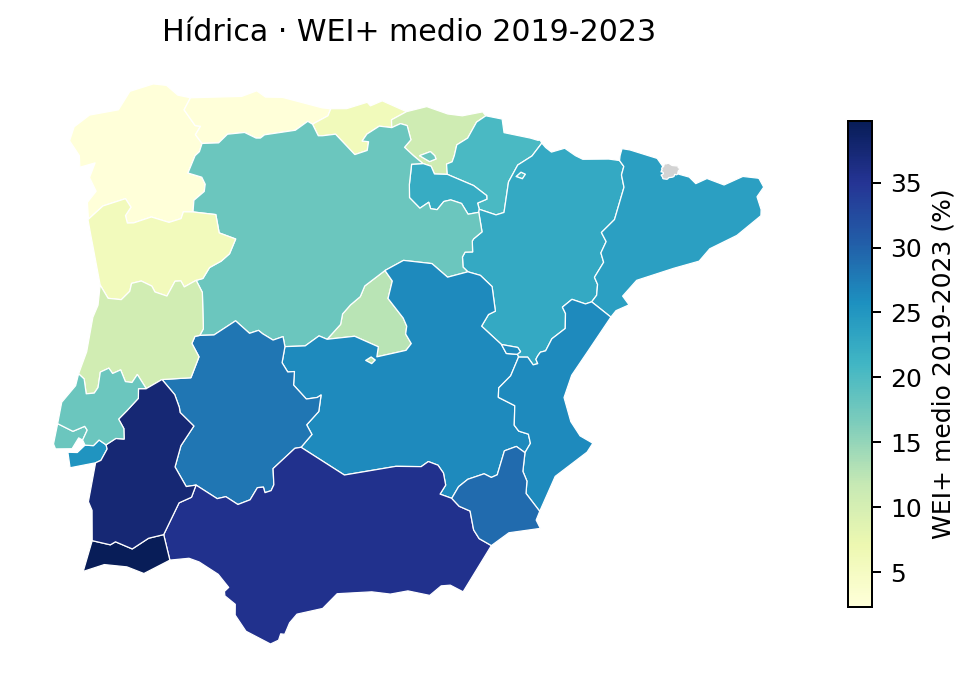

In [48]:
# Mapas y panel territorial
from IPython.display import Image

gdf_mapas_15a = gdf_maestro_definitivo_13b.copy()

# Un indicador representativo de cada familia
mapas_15a = [
    ("socioeconomica", "Socioeconómica",
     "tasa_desempleo", "Tasa de desempleo", "%"),
    ("corine", "CORINE",
     "corine_superficies_artificiales_pct",
     "Superficies artificiales", "%"),
    ("logistica", "Logística",
     "logistica_road_tramos_n",
     "Tramos viarios", "número"),
    ("pvgis", "PVGIS",
     "pvgis_produccion_anual_kwh_kwp",
     "Producción solar anual", "kWh/kWp"),
    ("ambiental", "Ambiental",
     "ambiental_area_protegida_pct",
     "Área protegida", "%"),
    ("electrica", "Eléctrica",
     "electrica_densidad_lineas_km_1000km2",
     "Densidad de líneas eléctricas", "km/1.000 km²"),
    ("digital", "Digital",
     "digital_torres_mastiles_1000km2",
     "Torres y mástiles", "unidades/1.000 km²"),
    ("climatica", "Climática",
     "temperatura_media_2m_c",
     "Temperatura media", "°C"),
    ("hidrica", "Hídrica",
     "hidrica_wei_media_ponderada_pct_2019_2023",
     "WEI+ medio 2019-2023", "%")
]
rutas_mapas_15a = []
bloques_html_15a = []

# Generación de los mapas
for nombre, familia, variable, titulo, unidad in mapas_15a:
    fig, ax = plt.subplots(figsize=(7, 5))

    gdf_mapas_15a.plot(
        column=variable,
        cmap="YlGnBu",
        legend=True,
        edgecolor="white",
        linewidth=0.5,
        missing_kwds={
            "color": "lightgrey",
            "label": "No disponible"
        },
        legend_kwds={
            "label": f"{titulo} ({unidad})",
            "shrink": 0.7
        },
        ax=ax
    )
    ax.set_title(f"{familia} · {titulo}")
    ax.axis("off")
    ruta_mapa = FIGURAS_DIR / f"mapa_{nombre}.png"

    fig.savefig(
        ruta_mapa,
        dpi=180,
        bbox_inches="tight"
    )
    plt.close(fig)
    rutas_mapas_15a.append(ruta_mapa)
    bloques_html_15a.append(
        f"""
        <section>
            <h2>{familia}</h2>
            <p>{titulo} ({unidad})</p>
            <img src="../figures/{ruta_mapa.name}">
        </section>
        """
    )

# Panel HTML con los nueve mapas
ruta_dashboard_15a = (
    DASHBOARD_DIR / "dashboard_territorial.html"
)
ruta_dashboard_15a.write_text(
    f"""
    <!DOCTYPE html>
    <html lang="es">
    <head>
        <meta charset="utf-8">
        <title>Panel territorial</title>
        <style>
            body {{
                font-family: Arial;
                max-width: 1200px;
                margin: 30px auto;
            }}
            main {{
                display: grid;
                grid-template-columns: repeat(2, 1fr);
                gap: 25px;
            }}
            section {{
                border: 1px solid #ddd;
                padding: 15px;
            }}
            img {{
                width: 100%;
            }}
        </style>
    </head>
    <body>
        <h1>Panel territorial del dataset maestro</h1>
        <p>
            Se muestra un indicador de cada familia analítica.
            El color gris representa información no disponible.
        </p>
        <main>{"".join(bloques_html_15a)}</main>
    </body>
    </html>
    """,
    encoding="utf-8"
)

# Validación
mapas_correctos_15a = (
    len(rutas_mapas_15a) == 9
    and all(
        ruta.exists() and ruta.stat().st_size > 0
        for ruta in rutas_mapas_15a
    )
)
dashboard_correcto_15a = (
    ruta_dashboard_15a.exists()
    and ruta_dashboard_15a.stat().st_size > 0
)
if not mapas_correctos_15a or not dashboard_correcto_15a:
    raise ValueError("Los mapas o el panel necesitan revisión.")

# Registro de control
pd.DataFrame([{
    "mapas_generados": len(rutas_mapas_15a),
    "dashboard_generado": dashboard_correcto_15a,
    "estado": "correcto"
}]).to_csv(
    MANIFEST_DIR / "control_mapas_dashboard.csv",
    index=False,
    encoding="utf-8-sig"
)

print("Mapas generados: 9")
print("Panel:", ruta_dashboard_15a)
print("Estado 15A: correcto")

display(
    Image(filename=str(FIGURAS_DIR / "mapa_hidrica.png"))
)

### Lectura de los mapas

Se han generado nueve mapas estáticos, uno por cada familia analítica, y un panel HTML que permite consultarlos conjuntamente. En el notebook se muestra únicamente el mapa hídrico como ejemplo.

Los 22 territorios NUTS 2 disponen de información completa. Andorra aparece sin datos en los mapas CORINE, ambiental e hídrico, sin aplicar imputaciones.

Cada mapa utiliza su propia escala de color. Por tanto, los colores permiten comparar territorios dentro de un mismo indicador, pero no entre mapas diferentes.

In [49]:
# ============================================================
# 15B. Inventario de productos finales
# ============================================================

productos_15b = [
    ruta_parquet_13c,
    ruta_csv_13d,
    ruta_gpkg_13e,
    ruta_catalogo_14a,
    ruta_resumen_14a,
    RELEASE_DIR / "muestra_dataset_final.csv",
    RELEASE_DIR / "muestra_dataset_final.xlsx",
    RELEASE_DIR / "cobertura_analitica_por_familia.csv",
    RELEASE_DIR / "cobertura_analitica_por_territorio.csv",
    ruta_dashboard_15a,
    *rutas_mapas_15a
]

# El bloque final debe contener exactamente 19 productos principales
if len(productos_15b) != 19:
    raise ValueError(
        f"Número inesperado de productos principales: "
        f"{len(productos_15b)}"
    )

# Comprobación individual de existencia y tamaño real
df_productos_15b = pd.DataFrame({
    "archivo": [ruta.name for ruta in productos_15b],
    "ruta": [str(ruta) for ruta in productos_15b],
    "existe": [ruta.exists() for ruta in productos_15b],
    "tamano_bytes": [
        ruta.stat().st_size
        if ruta.exists()
        else 0
        for ruta in productos_15b
    ]
})

df_productos_15b["tamano_kb"] = (
    df_productos_15b["tamano_bytes"] / 1024
).round(2)

problemas_15b = df_productos_15b[
    (~df_productos_15b["existe"])
    | (df_productos_15b["tamano_bytes"] <= 0)
]

if not problemas_15b.empty:
    display(problemas_15b)
    raise ValueError(
        "Hay productos finales ausentes o vacíos."
    )

# Inventario completo del Notebook 10
ruta_inventario_15b = (
    MANIFEST_DIR / "inventario_productos_finales.csv"
)

archivos_15b = [
    ruta
    for ruta in BASE_DIR.rglob("*")
    if (
        ruta.is_file()
        and ruta != ruta_inventario_15b
    )
]

df_inventario_15b = pd.DataFrame({
    "archivo": [ruta.name for ruta in archivos_15b],
    "ruta_relativa": [
        str(ruta.relative_to(BASE_DIR))
        for ruta in archivos_15b
    ],
    "tamano_kb": [
        round(ruta.stat().st_size / 1024, 2)
        for ruta in archivos_15b
    ]
})

df_inventario_15b.to_csv(
    ruta_inventario_15b,
    index=False,
    encoding="utf-8-sig"
)

print("Productos principales:", len(df_productos_15b))
print("Archivos inventariados:", len(df_inventario_15b))
print("Estado 15B: correcto")

display(
    df_productos_15b[
        ["archivo", "existe", "tamano_kb"]
    ]
)

Productos principales: 19
Archivos inventariados: 51
Estado 15B: correcto


,archivo,existe,tamano_kb
0,gdf_maestro_territorial_final_23x113.parquet,True,114.51
1,df_maestro_territorial_final_23x112.csv,True,35.54
2,gdf_maestro_territorial_final_23x113.gpkg,True,144.00
3,catalogo_tecnico_maestro_territorial_113_colum...,True,7.47
4,resumen_familias_maestro_territorial.csv,True,0.21
5,muestra_dataset_final.csv,True,1.04
6,muestra_dataset_final.xlsx,True,5.75
7,cobertura_analitica_por_familia.csv,True,0.22
8,cobertura_analitica_por_territorio.csv,True,0.76
9,dashboard_territorial.html,True,2.45


### Resultado del inventario

El inventario confirma la creación de los principales productos del Notebook 10: el maestro en tres formatos, el catálogo técnico, las tablas de cobertura, la muestra de datos, los nueve mapas estáticos y el panel territorial.

En total se han registrado 51 archivos. Esta cantidad se calcula directamente a partir de las carpetas generadas, sin establecer previamente un número fijo de archivos auxiliares.

In [50]:
# Paquete para el Notebook 11
import shutil

PAQUETE_16A = RELEASE_DIR / "paquete_analisis_notebook_11"
if PAQUETE_16A.exists():
    shutil.rmtree(PAQUETE_16A)
DATOS_16A = PAQUETE_16A / "01_datos"
DOCUMENTACION_16A = PAQUETE_16A / "02_documentacion"
CONTROLES_16A = PAQUETE_16A / "03_controles"
FIGURAS_16A = PAQUETE_16A / "04_visualizacion" / "figures"
DASHBOARDS_16A = PAQUETE_16A / "04_visualizacion" / "dashboards"

for carpeta in [
    DATOS_16A,
    DOCUMENTACION_16A,
    CONTROLES_16A,
    FIGURAS_16A,
    DASHBOARDS_16A
]:
    carpeta.mkdir(parents=True, exist_ok=True)

# Matrices para el análisis
columnas_16a = [
    COLUMNA_CLAVE,
    "nombre_territorio",
    "pais",
    "ambito_modelo",
    *variables_analiticas_14a
]
df_completo_16a = gdf_maestro_definitivo_13b[
    columnas_16a
].copy()

df_comparable_16a = (
    df_completo_16a[
        df_completo_16a["ambito_modelo"]
        == "NUTS2_comparable"
    ]
    .reset_index(drop=True)
)

# Guardamos una vista en CSV, Parquet y Excel
def guardar_vista_16a(df, nombre):
    rutas = [
        DATOS_16A / f"{nombre}.csv",
        DATOS_16A / f"{nombre}.parquet",
        DATOS_16A / f"{nombre}.xlsx"
    ]
    df.to_csv(
        rutas[0],
        index=False,
        encoding="utf-8-sig"
    )
    df.to_parquet(
        rutas[1],
        index=False
    )
    df.to_excel(
        rutas[2],
        index=False
    )
    return rutas

rutas_completo_16a = guardar_vista_16a(
    df_completo_16a,
    "dataset_analitico_completo_23x78"
)
rutas_comparable_16a = guardar_vista_16a(
    df_comparable_16a,
    "dataset_analitico_comparable_22x78"
)

# Copiamos el maestro
for ruta in [
    ruta_parquet_13c,
    ruta_csv_13d,
    ruta_gpkg_13e
]:
    shutil.copy2(ruta, DATOS_16A / ruta.name)

# Copiamos la documentación
documentos_16a = [
    ruta_catalogo_14a,
    ruta_resumen_14a,
    RELEASE_DIR / "cobertura_analitica_por_familia.csv",
    RELEASE_DIR / "cobertura_analitica_por_territorio.csv",
    RELEASE_DIR / "muestra_dataset_final.csv",
    RELEASE_DIR / "muestra_dataset_final.xlsx"
]
for ruta in documentos_16a:
    shutil.copy2(ruta, DOCUMENTACION_16A / ruta.name)

# Copiamos mapas y panel conservando las carpetas
for ruta in rutas_mapas_15a:
    shutil.copy2(ruta, FIGURAS_16A / ruta.name)
ruta_dashboard_paquete_16a = (
    DASHBOARDS_16A / ruta_dashboard_15a.name
)
shutil.copy2(
    ruta_dashboard_15a,
    ruta_dashboard_paquete_16a
)

# Copiamos controles disponibles
for ruta in [
    MANIFEST_DIR / "control_mapas_dashboard.csv",
    MANIFEST_DIR / "inventario_productos_finales.csv"
]:
    if ruta.exists():
        shutil.copy2(ruta, CONTROLES_16A / ruta.name)

# README
ruta_readme_16a = PAQUETE_16A / "README_Notebook_11.txt"

ruta_readme_16a.write_text(
    """
PAQUETE PARA EL NOTEBOOK 11
===========================
Matriz principal:
- 22 territorios NUTS 2
- 74 variables analíticas
- sin valores ausentes
Matriz completa:
- 23 territorios, incluyendo Andorra
- 20 valores ausentes en Andorra
- sin imputaciones

La matriz de 22 territorios será la entrada principal
para el EDA del Notebook 11.

Los análisis multivariantes y el modelo territorial
se desarrollarán en notebooks posteriores.
    """.strip(),
    encoding="utf-8"
)

# Validación
nulos_completo_16a = int(
    df_completo_16a[
        variables_analiticas_14a
    ].isna().sum().sum()
)
nulos_comparable_16a = int(
    df_comparable_16a[
        variables_analiticas_14a
    ].isna().sum().sum()
)
archivos_clave_16a = (
    rutas_completo_16a
    + rutas_comparable_16a
    + [ruta_dashboard_paquete_16a, ruta_readme_16a]
)
if (
    df_completo_16a.shape != (23, 78)
    or df_comparable_16a.shape != (22, 78)
    or nulos_completo_16a != 20
    or nulos_comparable_16a != 0
    or len(list(FIGURAS_16A.glob("*.png"))) != 9
    or not all(
        ruta.exists() and ruta.stat().st_size > 0
        for ruta in archivos_clave_16a
    )
):
    raise ValueError("El paquete necesita revisión.")

# Control
pd.DataFrame([{
    "vista_completa": "23x78",
    "vista_comparable": "22x78",
    "variables_analiticas": 74,
    "nulos_comparable": 0,
    "estado": "correcto"
}]).to_csv(
    CONTROLES_16A / "control_paquete_notebook_11.csv",
    index=False,
    encoding="utf-8-sig"
)

print("Vista completa:", df_completo_16a.shape)
print("Vista comparable:", df_comparable_16a.shape)
print("Variables analíticas: 74")
print("Paquete:", PAQUETE_16A)


Vista completa: (23, 78)
Vista comparable: (22, 78)
Variables analíticas: 74
Paquete: /kaggle/working/10_dataset_maestro_integracion_territorial_iberia/release/paquete_analisis_notebook_11


### Paquete para el Notebook 11

La matriz principal contiene 22 territorios NUTS 2, cuatro campos de identificación y 74 variables analíticas, sin valores ausentes.

También se conserva una matriz completa con Andorra. Este territorio dispone de 54 variables y mantiene 20 valores ausentes, sin aplicar imputaciones.

La matriz comparable queda preparada para el EDA del Notebook 11. Los análisis multivariantes y el modelo territorial se desarrollarán en notebooks posteriores.

In [51]:
# ZIP y backup final
import zipfile

ZIP_ANALISIS_16B = (
    RELEASE_DIR
    / "paquete_analisis_notebook_11_FINAL.zip"
)
ZIP_BACKUP_16B = (
    Path("/kaggle/working")
    / "BACKUP_NOTEBOOK_10_PRODUCTOS_FINAL.zip"
)

# Archivos necesarios para continuar en el Notebook 11
archivos_clave_16b = [
    DATOS_16A / "dataset_analitico_comparable_22x78.parquet",
    DATOS_16A / "dataset_analitico_completo_23x78.parquet",
    DATOS_16A / "gdf_maestro_territorial_final_23x113.parquet",
    DATOS_16A / "gdf_maestro_territorial_final_23x113.gpkg",
    DATOS_16A / "df_maestro_territorial_final_23x112.csv",
    DOCUMENTACION_16A
        / "catalogo_tecnico_maestro_territorial_113_columnas.csv",
    DOCUMENTACION_16A
        / "resumen_familias_maestro_territorial.csv",
    CONTROLES_16A / "control_paquete_notebook_11.csv",
    PAQUETE_16A / "README_Notebook_11.txt"
]

# Comprobamos los nueve archivos
if not all(
    ruta.exists() and ruta.stat().st_size > 0
    for ruta in archivos_clave_16b
):
    raise FileNotFoundError("Faltan archivos clave.")

# Manifiesto sencillo
df_manifiesto_16b = pd.DataFrame({
    "archivo": [
        ruta.name
        for ruta in archivos_clave_16b
    ],
    "ruta_relativa": [
        str(ruta.relative_to(PAQUETE_16A))
        for ruta in archivos_clave_16b
    ],
    "tamano_kb": [
        round(ruta.stat().st_size / 1024, 2)
        for ruta in archivos_clave_16b
    ]
})
df_manifiesto_16b.to_csv(
    CONTROLES_16A / "manifiesto_archivos_clave.csv",
    index=False,
    encoding="utf-8-sig"
)

# Función para comprimir una carpeta
def crear_zip_16b(carpeta, destino):
    if destino.exists():
        destino.unlink()

    with zipfile.ZipFile(
        destino,
        "w",
        zipfile.ZIP_DEFLATED
    ) as archivo_zip:
        for ruta in carpeta.rglob("*"):
            if ruta.is_file():
                archivo_zip.write(
                    ruta,
                    arcname=str(
                        Path(carpeta.name)
                        / ruta.relative_to(carpeta)
                    )
                )

# Creamos los dos ZIP
crear_zip_16b(
    PAQUETE_16A,
    ZIP_ANALISIS_16B
)
crear_zip_16b(
    BASE_DIR,
    ZIP_BACKUP_16B
)

# Validación
with zipfile.ZipFile(
    ZIP_ANALISIS_16B
) as archivo_zip:
    archivos_zip_16b = archivo_zip.namelist()
    error_analisis_16b = archivo_zip.testzip()

with zipfile.ZipFile(
    ZIP_BACKUP_16B
) as archivo_zip:
    error_backup_16b = archivo_zip.testzip()
if (
    error_analisis_16b is not None
    or error_backup_16b is not None
):
    raise ValueError("Alguno de los ZIP contiene errores.")

print("Archivos clave: 9")
print("Archivos ZIP:", len(archivos_zip_16b))
print(
    "Tamaño ZIP análisis:",
    round(ZIP_ANALISIS_16B.stat().st_size / 1024**2, 2),
    "MB"
)
print(
    "Tamaño backup:",
    round(ZIP_BACKUP_16B.stat().st_size / 1024**2, 2),
    "MB"
)
print("ZIP Notebook 11:", ZIP_ANALISIS_16B)
print("Backup Notebook 10:", ZIP_BACKUP_16B)

Archivos clave: 9
Archivos ZIP: 30
Tamaño ZIP análisis: 0.96 MB
Tamaño backup: 209.36 MB
ZIP Notebook 11: /kaggle/working/10_dataset_maestro_integracion_territorial_iberia/release/paquete_analisis_notebook_11_FINAL.zip
Backup Notebook 10: /kaggle/working/BACKUP_NOTEBOOK_10_PRODUCTOS_FINAL.zip


## Cierre del Notebook 10

El dataset maestro final contiene 23 territorios y 113 columnas. De ellas, 74 son variables analíticas distribuidas entre nueve familias.

Para el Notebook 11 se ha preparado una matriz principal con 22 territorios NUTS 2, cuatro campos de identificación y las 74 variables analíticas, sin valores ausentes.

También se conserva una matriz complementaria con Andorra, que mantiene 20 valores ausentes en CORINE, ambiental e hídrica, sin aplicar imputaciones.

El proceso queda documentado mediante el catálogo técnico, los controles, los mapas y el paquete final. El Notebook 11 se dedicará exclusivamente al EDA, sin repetir las etapas de adquisición e integración. Los análisis multivariantes y el modelo territorial se desarrollarán posteriormente.